# In Silico `Toxicity` prediction for `Ebola` Antiviral Candidates

This workflow uses `admet_ai` predictions to perform a **rule-based safety triage** of candidate molecules.

The goal is to support **early prioritization**, not to make definitive toxicity claims.

We separate predictions into three categories:

- **Core toxicity risk**: direct safety concerns such as hERG, DILI, AMES, and ClinTox
- **Mechanistic alerts**: stress-response and nuclear-receptor pathway signals
- **ADME / metabolism liabilities**: permeability, transporter, and CYP-related liabilities that may affect developability but do not necessarily imply intrinsic toxicity

In [41]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

In [42]:
import numpy as np
import pandas as pd
import pubchempy as pcp
from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem
from admet_ai import ADMETModel
import matplotlib.pyplot as plt

In [43]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
resultsDir = os.path.join(dataDir, 'Results/')
saveDir = os.path.join(resultsDir, "combinedEbolaVirus_bestMACAW/")
DORANETmoleculesDataDir = os.path.join(dataDir, 'DORAnet_molecules/')
ARTresultsDir = os.path.join(dataDir, 'Results/combinedEbolaVirus_bestMACAW/')
os.makedirs(saveDir, exist_ok=True)

## Check toxicty for `buyable` AntiviralsData set

In [44]:
combinedEbolaVirus_wART_Buyable_predicted_all = pd.read_csv(ARTresultsDir + 'Ebola_all_Buyable_AntiVirals_wARTprediction.csv')
max_val = combinedEbolaVirus_wART_Buyable_predicted_all['pPotency_prediction'].max()
min_val = combinedEbolaVirus_wART_Buyable_predicted_all['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
combinedEbolaVirus_wART_Buyable_predicted_all

pPotency_prediction range: 4.220 → 6.778


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,COCC(C)NC(=O)Nc1nnc(C2CC2)s1,4.804306,0.616552,3.595864,6.012748,0.000016,9.710723e-07,0.000254
1,Cn1c(=O)ccn(CC(=O)NCC2CC2)c1=O,4.842776,0.613032,3.641234,6.044319,0.000014,9.029870e-07,0.000228
2,CCN(CC)CCNC(=O)c1cccnc1N1CCOCC1,4.464808,0.609161,3.270852,5.658764,0.000034,2.193997e-06,0.000536
3,CCC(CNC(=O)Cc1c(C)noc1C)N1CCCC1,4.862195,0.613532,3.659672,6.064719,0.000014,8.615512e-07,0.000219
4,CCC(C)(CNC(=O)Cn1ccccc1=O)N1CCOCC1,4.822719,0.611690,3.623807,6.021632,0.000015,9.514116e-07,0.000238
...,...,...,...,...,...,...,...,...
113180,CCOC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(OC...,5.884116,0.608740,4.690986,7.077247,0.000001,8.370523e-08,0.000020
113181,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(Br)cc4)cc(C(F...,5.744996,0.609386,4.550599,6.939392,0.000002,1.149761e-07,0.000028
113182,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,5.681098,0.609261,4.486948,6.875249,0.000002,1.332758e-07,0.000033
113183,COc1cc(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(Br)cc4)...,5.670537,0.609623,4.475676,6.865398,0.000002,1.363333e-07,0.000033


### Read predicted ADMET properties for all candidate SMILES

In [45]:
combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity = pd.read_csv(ARTresultsDir + 'Ebola_all_Buyable_AntiVirals_wARTprediction_wToxicity.csv')
max_val = combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity['pPotency_prediction'].max()
min_val = combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity

pPotency_prediction range: 4.220 → 6.772


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,logP,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,COCC(C)NC(=O)Nc1nnc(C2CC2)s1,4.804306,0.616552,3.595864,6.012748,0.000016,9.710723e-07,0.000254,256.331,1.57190,...,87.592090,73.322993,71.074060,35.284994,26.017836,38.542071,57.386584,35.595192,54.711128,19.968980
1,Cn1c(=O)ccn(CC(=O)NCC2CC2)c1=O,4.842776,0.613032,3.641234,6.044319,0.000014,9.029870e-07,0.000228,237.259,-0.92680,...,97.014347,50.368360,41.295076,47.266382,8.763086,54.439705,19.193486,14.346646,85.963552,27.762699
2,CCN(CC)CCNC(=O)c1cccnc1N1CCOCC1,4.464808,0.609161,3.270852,5.658764,0.000034,2.193997e-06,0.000536,306.410,0.98980,...,79.798371,56.921287,25.668864,74.563784,14.734393,47.150058,20.938348,3.722373,88.367584,94.222567
3,CCC(CNC(=O)Cc1c(C)noc1C)N1CCCC1,4.862195,0.613532,3.659672,6.064719,0.000014,8.615512e-07,0.000219,279.384,1.82454,...,58.549826,39.976735,28.421869,48.856146,34.703373,62.815045,25.242342,8.181466,86.545173,59.170221
4,CCC(C)(CNC(=O)Cn1ccccc1=O)N1CCOCC1,4.822719,0.611690,3.623807,6.021632,0.000015,9.514116e-07,0.000238,307.394,0.46540,...,65.529275,69.833269,20.589376,56.184568,17.836371,32.880962,21.170997,5.971307,88.018612,73.206669
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62704,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(OC)cc4)cc(C(F...,5.832028,0.608904,4.638575,7.025480,0.000001,9.430177e-08,0.000023,518.517,5.53104,...,65.568050,82.551377,97.557193,96.859248,54.556029,90.151221,94.067468,88.600233,7.987592,42.535867
62705,COC(=O)c1ccc(C(=O)OC)c(NC(=O)c2cc3nc(-c4ccc(Cl...,5.921809,0.608071,4.729990,7.113628,0.000001,7.697901e-08,0.000019,532.862,4.89400,...,67.080264,70.298565,94.804188,97.363319,46.180690,58.123304,94.416440,85.149283,3.218302,22.644436
62706,O=C(Nc1cccc2c1OCO2)c1nn2c(C(F)(F)F)cc(-c3ccc(B...,5.494073,0.609462,4.299527,6.688619,0.000003,2.048239e-07,0.000050,539.695,5.81200,...,66.110896,61.729352,83.404420,96.665374,53.315238,95.036836,94.338891,89.414502,0.426522,26.521908
62707,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,5.765021,0.609324,4.570745,6.959296,0.000002,1.098256e-07,0.000027,555.003,6.35520,...,71.849554,70.104692,95.308259,96.316402,64.055836,94.998061,94.145017,89.414502,5.195812,73.594416


### Retain potency predictions along with toxicity, mechanistic, and ADME-related endpoints

In [46]:
# Potency-related columns
potencyCols = [
    "SMILES",
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]

# Mechanistic alert endpoints
# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = potencyCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity.columns
]

combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity = combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity[selectedCols].copy()

print("Filtered dataframe shape:", combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity.shape)
combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity.head()

Filtered dataframe shape: (62709, 41)


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,AMES,hERG,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,COCC(C)NC(=O)Nc1nnc(C2CC2)s1,4.804306,0.616552,3.595864,6.012748,0.000016,9.710723e-07,0.000254,0.239500,0.016462,...,0.855482,0.945640,0.076049,0.350395,0.290878,0.134904,0.071786,0.002689,0.382473,0.005204
1,Cn1c(=O)ccn(CC(=O)NCC2CC2)c1=O,4.842776,0.613032,3.641234,6.044319,0.000014,9.029870e-07,0.000228,0.152839,0.008214,...,0.636528,0.914472,0.003674,0.034129,0.375321,0.005663,0.109176,0.002534,0.404691,0.004057
2,CCN(CC)CCNC(=O)c1cccnc1N1CCOCC1,4.464808,0.609161,3.270852,5.658764,0.000034,2.193997e-06,0.000536,0.638718,0.690349,...,0.914802,0.946715,0.091784,0.044804,0.168623,0.005473,0.320181,0.105699,0.264736,0.014986
3,CCC(CNC(=O)Cc1c(C)noc1C)N1CCCC1,4.862195,0.613532,3.659672,6.064719,0.000014,8.615512e-07,0.000219,0.121497,0.362352,...,0.894814,0.896890,0.003908,0.038184,0.042111,0.001958,0.348713,0.191350,0.608893,0.005841
4,CCC(C)(CNC(=O)Cn1ccccc1=O)N1CCOCC1,4.822719,0.611690,3.623807,6.021632,0.000015,9.514116e-07,0.000238,0.197948,0.221449,...,0.722896,0.823651,0.000397,0.065866,0.074823,0.006422,0.053373,0.042926,0.389752,0.044676


### Read ADMET endpoints of the FDA approved Drug data from `Drugbank`

In [47]:
drugBankDrugData_approved_ADMET_summary = pd.read_csv(dataDir + 'Toxicity/DrugBank/drugBankDrugData_ADMET_summary.csv')
drugBankDrugData_approved_ADMET_summary

,Endpoint,Min,Max,Range,Mean,Std
0,AMES,4.580234e-05,0.999994,0.999949,0.299619,0.249049
1,hERG,5.135011e-05,0.997788,0.997737,0.434110,0.340795
2,DILI,1.172916e-05,0.998585,0.998573,0.565484,0.337805
3,ClinTox,6.131192e-09,0.955574,0.955574,0.217150,0.212429
4,Carcinogens_Lagunin,3.302558e-04,0.991252,0.990921,0.230227,0.199003
5,Skin_Reaction,6.183962e-03,0.999993,0.993809,0.433260,0.253876
6,LD50_Zhu,-4.707379e-02,6.023548,6.070622,2.546885,0.656044
7,SR-ARE,2.767653e-05,0.999029,0.999002,0.272911,0.251478
8,SR-ATAD5,3.475998e-13,0.986187,0.986187,0.058122,0.110646
9,SR-HSE,1.241251e-11,0.965706,0.965706,0.068353,0.120833


### Filter compounds based on the results from Drugbank's `ADMET` summary

In [48]:
# ── Build range lookup dict from summary dataframe ─────────────────────────────
# Ensure Endpoint is the index and numeric types are correct
summaryDF = drugBankDrugData_approved_ADMET_summary.copy()

if "Endpoint" in summaryDF.columns:
    summaryDF = summaryDF.set_index("Endpoint")

summaryDF = summaryDF.astype(float)

rangeDict = summaryDF[["Min", "Max"]].to_dict(orient="index")

# ── Range mask builder ─────────────────────────────────────────────────────────
def buildRangeMask(df, endpointCols, rangeDict):
    """
    Returns a boolean Series: True if ALL available endpoints in endpointCols
    fall within [Min, Max] defined in rangeDict.
    Skips endpoints missing from either the dataframe or the rangeDict.
    """
    mask = pd.Series(True, index=df.index)
    skipped = []
    applied = []

    for col in endpointCols:
        if col not in df.columns or col not in rangeDict:
            skipped.append(col)
            continue
        colMin = rangeDict[col]["Min"]
        colMax = rangeDict[col]["Max"]
        mask = mask & df[col].between(colMin, colMax, inclusive="both")
        applied.append(col)

    return mask, applied, skipped


df = combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity.copy()
total = len(df)

# ── Apply masks per category ───────────────────────────────────────────────────
coreMask,        coreApplied,        coreSkipped        = buildRangeMask(df, coreToxicityCols,     rangeDict)
mechanisticMask, mechanisticApplied, mechanisticSkipped = buildRangeMask(df, mechanisticAlertCols, rangeDict)
admeMask,        admeApplied,        admeSkipped        = buildRangeMask(df, admeLiabilityCols,    rangeDict)

# Combined: must pass all three categories simultaneously
combinedMask = coreMask & mechanisticMask & admeMask

# ── Filter dataframes ──────────────────────────────────────────────────────────
df_coreFiltered        = df[coreMask].reset_index(drop=True)
df_mechanisticFiltered = df[mechanisticMask].reset_index(drop=True)
df_admeFiltered        = df[admeMask].reset_index(drop=True)
df_allFiltered         = df[combinedMask].reset_index(drop=True)

# ── Report 
print("         DrugBank Approved Range Filtering Summary")
print(f"Total input molecules: {total}")

print(f"\n──> Core Toxicity Endpoints ")
print(f"  Endpoints applied : {coreApplied}")
print(f"  Endpoints skipped : {coreSkipped}")
print(f"  Passing molecules : {len(df_coreFiltered)} / {total}  ({len(df_coreFiltered)/total*100:.2f}%)")

print(f"\n──> Mechanistic Alert Endpoints ")
print(f"  Endpoints applied : {mechanisticApplied}")
print(f"  Endpoints skipped : {mechanisticSkipped}")
print(f"  Passing molecules : {len(df_mechanisticFiltered)} / {total}  ({len(df_mechanisticFiltered)/total*100:.2f}%)")

print(f"\n──> ADME / Metabolism Liability Endpoints ")
print(f"  Endpoints applied : {admeApplied}")
print(f"  Endpoints skipped : {admeSkipped}")
print(f"  Passing molecules : {len(df_admeFiltered)} / {total}  ({len(df_admeFiltered)/total*100:.2f}%)")

print(f"\n──> Combined (ALL categories must pass) ")
print(f"  Passing molecules : {len(df_allFiltered)} / {total}  ({len(df_allFiltered)/total*100:.2f}%)")
print("=" * 65)

# ── Inspect results ────────────────────────────────────────────────────────────
print("\nCombined filtered dataframe shape:", df_allFiltered.shape)
combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity = df_allFiltered.copy()
combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity

         DrugBank Approved Range Filtering Summary
Total input molecules: 62709

──> Core Toxicity Endpoints 
  Endpoints applied : ['AMES', 'hERG', 'DILI', 'ClinTox', 'Carcinogens_Lagunin', 'Skin_Reaction', 'LD50_Zhu']
  Endpoints skipped : []
  Passing molecules : 62709 / 62709  (100.00%)

──> Mechanistic Alert Endpoints 
  Endpoints applied : ['SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53', 'NR-AR-LBD', 'NR-AR', 'NR-AhR', 'NR-Aromatase', 'NR-ER-LBD', 'NR-ER', 'NR-PPAR-gamma']
  Endpoints skipped : []
  Passing molecules : 62678 / 62709  (99.95%)

──> ADME / Metabolism Liability Endpoints 
  Endpoints applied : ['BBB_Martins', 'Pgp_Broccatelli', 'Caco2_Wang', 'HIA_Hou', 'PAMPA_NCATS', 'Bioavailability_Ma', 'CYP1A2_Veith', 'CYP2C19_Veith', 'CYP2C9_Substrate_CarbonMangels', 'CYP2C9_Veith', 'CYP2D6_Substrate_CarbonMangels', 'CYP2D6_Veith', 'CYP3A4_Substrate_CarbonMangels', 'CYP3A4_Veith']
  Endpoints skipped : []
  Passing molecules : 62664 / 62709  (99.93%)

──> Combined (ALL categ

,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,AMES,hERG,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,COCC(C)NC(=O)Nc1nnc(C2CC2)s1,4.804306,0.616552,3.595864,6.012748,0.000016,9.710723e-07,0.000254,0.239500,0.016462,...,0.855482,0.945640,0.076049,0.350395,0.290878,0.134904,0.071786,0.002689,0.382473,0.005204
1,Cn1c(=O)ccn(CC(=O)NCC2CC2)c1=O,4.842776,0.613032,3.641234,6.044319,0.000014,9.029870e-07,0.000228,0.152839,0.008214,...,0.636528,0.914472,0.003674,0.034129,0.375321,0.005663,0.109176,0.002534,0.404691,0.004057
2,CCN(CC)CCNC(=O)c1cccnc1N1CCOCC1,4.464808,0.609161,3.270852,5.658764,0.000034,2.193997e-06,0.000536,0.638718,0.690349,...,0.914802,0.946715,0.091784,0.044804,0.168623,0.005473,0.320181,0.105699,0.264736,0.014986
3,CCC(CNC(=O)Cc1c(C)noc1C)N1CCCC1,4.862195,0.613532,3.659672,6.064719,0.000014,8.615512e-07,0.000219,0.121497,0.362352,...,0.894814,0.896890,0.003908,0.038184,0.042111,0.001958,0.348713,0.191350,0.608893,0.005841
4,CCC(C)(CNC(=O)Cn1ccccc1=O)N1CCOCC1,4.822719,0.611690,3.623807,6.021632,0.000015,9.514116e-07,0.000238,0.197948,0.221449,...,0.722896,0.823651,0.000397,0.065866,0.074823,0.006422,0.053373,0.042926,0.389752,0.044676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62629,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(OC)cc4)cc(C(F...,5.832028,0.608904,4.638575,7.025480,0.000001,9.430177e-08,0.000023,0.379639,0.834468,...,0.855666,0.872495,0.209174,0.393133,0.215278,0.642392,0.051432,0.022186,0.674206,0.562916
62630,COC(=O)c1ccc(C(=O)OC)c(NC(=O)c2cc3nc(-c4ccc(Cl...,5.921809,0.608071,4.729990,7.113628,0.000001,7.697901e-08,0.000019,0.157411,0.834515,...,0.794991,0.778819,0.435742,0.524126,0.195368,0.676106,0.049123,0.023144,0.520809,0.368816
62631,O=C(Nc1cccc2c1OCO2)c1nn2c(C(F)(F)F)cc(-c3ccc(B...,5.494073,0.609462,4.299527,6.688619,0.000003,2.048239e-07,0.000050,0.309636,0.857048,...,0.892466,0.842728,0.755063,0.731413,0.206958,0.833080,0.051621,0.144014,0.632007,0.499604
62632,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,5.765021,0.609324,4.570745,6.959296,0.000002,1.098256e-07,0.000027,0.405114,0.751762,...,0.911196,0.761689,0.464999,0.667812,0.161532,0.883468,0.026396,0.042084,0.686805,0.484413


### Multiparameter optimization (MPO) framework based ADMET scoring

We replaced simple arithmetic averaging with a weighted desirability-based multiparameter optimization (MPO) framework. Each ADMET endpoint was converted to a 0–1 desirability value, where `1 --> favorable` and `0 --> unfavorable` profile. Category-level scores were then combined using weighted geometric means, following the same general pattern used in QED and ADMET-score approaches.

**References**

1. ADMET-score – a comprehensive scoring function for evaluation of chemical drug-likeness (https://pubs.rsc.org/en/content/articlelanding/2019/md/c8md00472b)
2. Quantifying the chemical beauty of drugs (https://www.nature.com/articles/nchem.1243)

In [49]:
df = combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity.copy()


# Endpoint groups
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu",
]

mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma",
]

# Define these lists according to how you want to treat directionality
# lower-is-better => toxicity/liability style probabilities
admeLowerIsBetter = [
    "Pgp_Broccatelli",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith",
]

# higher-is-better => absorption / permeability / bioavailability style endpoints
admeHigherIsBetter = [
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
]

# Optional / context-dependent endpoint
# For non-CNS antivirals, you may wish to penalize BBB penetration.
# For CNS programs, you may want the opposite or exclude it from the score.
includeBBB = False
if includeBBB and "BBB_Martins" in df.columns:
    admeLowerIsBetter = admeLowerIsBetter + ["BBB_Martins"]


# Utilities
epsilon = 1e-6

def clip01(series):
    return series.clip(lower=epsilon, upper=1 - epsilon)

def desirabilityFromRiskProbability(series):
    """
    For toxicity/liability probabilities:
    lower risk is better -> desirability = 1 - p
    """
    return clip01(1 - series)

def desirabilityFromBenefitProbability(series):
    """
    For favorable probabilities/scores already in [0,1]:
    higher is better -> desirability = p
    """
    return clip01(series)

def desirabilityFromLD50(series, lowerQuantile=0.10, upperQuantile=0.90):
    """
    LD50_Zhu is treated as a regression-style acute toxicity endpoint.
    Higher LD50_Zhu implies greater acute toxicity risk.
    Map lower values -> high desirability, higher values -> low desirability.

    Uses a robust percentile-based linear desirability transform so the score
    is less sensitive to extreme outliers than plain min-max scaling.
    """
    qLow = series.quantile(lowerQuantile)
    qHigh = series.quantile(upperQuantile)

    if pd.isna(qLow) or pd.isna(qHigh) or qHigh == qLow:
        return pd.Series(0.5, index=series.index)

    # lower LD50_Zhu = better, higher = worse
    desirability = 1 - ((series - qLow) / (qHigh - qLow))
    return clip01(desirability)

def weightedGeometricMean(dfValues, weightsDict):
    """
    Compute weighted geometric mean across available columns only.
    """
    availableCols = [col for col in weightsDict if col in dfValues.columns]
    if len(availableCols) == 0:
        return pd.Series(np.nan, index=dfValues.index)

    weights = np.array([weightsDict[col] for col in availableCols], dtype=float)
    weights = weights / weights.sum()

    values = dfValues[availableCols].copy()
    values = values.clip(lower=epsilon, upper=1 - epsilon)

    logWeighted = np.log(values).mul(weights, axis=1).sum(axis=1)
    return np.exp(logWeighted)

# -----------------------------------------------------------------------------
# 1. Core toxicity desirability
# -----------------------------------------------------------------------------
coreWeights = {
    "AMES": 1.0,
    "hERG": 1.5,
    "DILI": 1.5,
    "ClinTox": 1.5,
    "Carcinogens_Lagunin": 1.0,
    "Skin_Reaction": 0.5,
    "LD50_Zhu": 1.25,
}

coreDesirabilityDF = pd.DataFrame(index=df.index)

for colName in coreToxicityCols:
    if colName not in df.columns:
        continue

    if colName == "LD50_Zhu":
        coreDesirabilityDF[colName] = desirabilityFromLD50(df[colName])
    else:
        coreDesirabilityDF[colName] = desirabilityFromRiskProbability(df[colName])

df["Core_Toxicity_Desirability"] = weightedGeometricMean(coreDesirabilityDF, coreWeights)

# Optional inverse form if you want "higher = worse"
df["Core_Toxicity_Score"] = 1 - df["Core_Toxicity_Desirability"]

# -----------------------------------------------------------------------------
# 2. Mechanistic alert desirability
# -----------------------------------------------------------------------------
mechWeights = {
    "SR-ARE": 1.0,
    "SR-ATAD5": 1.0,
    "SR-HSE": 0.75,
    "SR-MMP": 1.25,
    "SR-p53": 1.0,
    "NR-AR-LBD": 0.75,
    "NR-AR": 0.75,
    "NR-AhR": 0.75,
    "NR-Aromatase": 0.75,
    "NR-ER-LBD": 0.75,
    "NR-ER": 0.75,
    "NR-PPAR-gamma": 0.5,
}

mechDesirabilityDF = pd.DataFrame(index=df.index)
for colName in mechanisticAlertCols:
    if colName in df.columns:
        mechDesirabilityDF[colName] = desirabilityFromRiskProbability(df[colName])

df["Mechanistic_Alert_Desirability"] = weightedGeometricMean(mechDesirabilityDF, mechWeights)
df["Mechanistic_Alert_Score"] = 1 - df["Mechanistic_Alert_Desirability"]

# -----------------------------------------------------------------------------
# 3. ADME liability desirability
# -----------------------------------------------------------------------------
admeWeights = {
    "BBB_Martins": 0.5,   # context dependent
    "Pgp_Broccatelli": 1.0,
    "Caco2_Wang": 1.0,
    "HIA_Hou": 1.0,
    "PAMPA_NCATS": 0.75,
    "Bioavailability_Ma": 1.25,
    "CYP1A2_Veith": 1.0,
    "CYP2C19_Veith": 1.0,
    "CYP2C9_Substrate_CarbonMangels": 0.75,
    "CYP2C9_Veith": 1.0,
    "CYP2D6_Substrate_CarbonMangels": 0.75,
    "CYP2D6_Veith": 1.0,
    "CYP3A4_Substrate_CarbonMangels": 0.75,
    "CYP3A4_Veith": 1.0,
}

admeDesirabilityDF = pd.DataFrame(index=df.index)

for colName in admeLowerIsBetter:
    if colName in df.columns:
        admeDesirabilityDF[colName] = desirabilityFromRiskProbability(df[colName])

for colName in admeHigherIsBetter:
    if colName in df.columns:
        admeDesirabilityDF[colName] = desirabilityFromBenefitProbability(df[colName])

df["ADME_Desirability"] = weightedGeometricMean(admeDesirabilityDF, admeWeights)
df["ADME_Liability_Score"] = 1 - df["ADME_Desirability"]

# -----------------------------------------------------------------------------
# 4. Final MPO-style safety score
# -----------------------------------------------------------------------------
# Higher desirability = better
# We give core toxicity the highest influence, then ADME, then mechanistic alerts.
componentDesirabilityDF = pd.DataFrame({
    "Core_Toxicity_Desirability": df["Core_Toxicity_Desirability"],
    "Mechanistic_Alert_Desirability": df["Mechanistic_Alert_Desirability"],
    "ADME_Desirability": df["ADME_Desirability"],
})

componentWeights = {
    "Core_Toxicity_Desirability": 0.50,
    "Mechanistic_Alert_Desirability": 0.20,
    "ADME_Desirability": 0.30,
}

df["Safety_MPO_Desirability"] = weightedGeometricMean(
    componentDesirabilityDF,
    componentWeights
)

# Optional inverse form if you want higher = worse
df["Safety_MPO_RiskScore"] = 1 - df["Safety_MPO_Desirability"]

# -----------------------------------------------------------------------------
# 5. Markdown-style explanation column
# -----------------------------------------------------------------------------
markdownNote = (
    "Composite scores were computed using a weighted desirability-based MPO framework. "
    "Each endpoint was transformed to a 0–1 desirability value, then combined with a "
    "weighted geometric mean. Core toxicity used AMES, hERG, DILI, ClinTox, "
    "Carcinogens_Lagunin, Skin_Reaction, and LD50_Zhu; mechanistic score used SR/NR "
    "alerts; ADME score used direction-adjusted absorption, transporter, and CYP endpoints. "
    "This follows the general scoring pattern used in QED and ADMET-score literature."
)

df["Scoring_Method_Markdown"] = markdownNote

# -----------------------------------------------------------------------------
# 6. Final output
# -----------------------------------------------------------------------------
combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity_sorted = df[
    [
        "SMILES",
        "pPotency_prediction",
        "pPotency_std",
        "Core_Toxicity_Desirability",
        "Core_Toxicity_Score",
        "Mechanistic_Alert_Desirability",
        "Mechanistic_Alert_Score",
        "ADME_Desirability",
        "ADME_Liability_Score",
        "Safety_MPO_Desirability",
        "Safety_MPO_RiskScore",
        "Scoring_Method_Markdown",
    ]
].copy()

combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity_sorted

,SMILES,pPotency_prediction,pPotency_std,Core_Toxicity_Desirability,Core_Toxicity_Score,Mechanistic_Alert_Desirability,Mechanistic_Alert_Score,ADME_Desirability,ADME_Liability_Score,Safety_MPO_Desirability,Safety_MPO_RiskScore,Scoring_Method_Markdown
0,COCC(C)NC(=O)Nc1nnc(C2CC2)s1,4.804306,0.616552,0.636557,0.363443,0.941390,0.058610,0.285699,0.714301,0.541309,0.458691,Composite scores were computed using a weighte...
1,Cn1c(=O)ccn(CC(=O)NCC2CC2)c1=O,4.842776,0.613032,0.760823,0.239177,0.993369,0.006631,0.290306,0.709694,0.601064,0.398936,Composite scores were computed using a weighte...
2,CCN(CC)CCNC(=O)c1cccnc1N1CCOCC1,4.464808,0.609161,0.457791,0.542209,0.990436,0.009564,0.296523,0.703477,0.468939,0.531061,Composite scores were computed using a weighte...
3,CCC(CNC(=O)Cc1c(C)noc1C)N1CCCC1,4.862195,0.613532,0.666017,0.333983,0.989911,0.010089,0.285296,0.714704,0.559050,0.440950,Composite scores were computed using a weighte...
4,CCC(C)(CNC(=O)Cn1ccccc1=O)N1CCOCC1,4.822719,0.611690,0.733089,0.266911,0.991515,0.008485,0.295221,0.704779,0.592765,0.407235,Composite scores were computed using a weighte...
...,...,...,...,...,...,...,...,...,...,...,...,...
62629,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(OC)cc4)cc(C(F...,5.832028,0.608904,0.038853,0.961147,0.630280,0.369720,0.186609,0.813391,0.108617,0.891383,Composite scores were computed using a weighte...
62630,COC(=O)c1ccc(C(=O)OC)c(NC(=O)c2cc3nc(-c4ccc(Cl...,5.921809,0.608071,0.267234,0.732766,0.726707,0.273293,0.180257,0.819743,0.290058,0.709942,Composite scores were computed using a weighte...
62631,O=C(Nc1cccc2c1OCO2)c1nn2c(C(F)(F)F)cc(-c3ccc(B...,5.494073,0.609462,0.032629,0.967371,0.434325,0.565675,0.152961,0.847039,0.087045,0.912955,Composite scores were computed using a weighte...
62632,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,5.765021,0.609324,0.045632,0.954368,0.512726,0.487274,0.158066,0.841934,0.107465,0.892535,Composite scores were computed using a weighte...


### Define filter for compound ranking based on `ADMET` scores

In [50]:
pPotency_prediction_cutoff = 5
Core_Toxicity_cutoff = 0.3
Mechanistic_Alert_cutoff = 0.3
ADME_Liability_cutoff = 0.3

In [51]:
combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity_core = (
    combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity_sorted[
        (combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity_sorted["pPotency_prediction"] > pPotency_prediction_cutoff) &
        (combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity_sorted["Core_Toxicity_Score"] < Core_Toxicity_cutoff)
    ]
    .reset_index(drop=True)
)

combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity_core
combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity_core.to_csv(resultsDir + 
                                                                           'combinedEbolaVirus_wART_Buyable_predicted_all_nonToxic_core.csv', index=False, encoding="utf-8")

### Plot full distribution + highlighted filtered dataframe

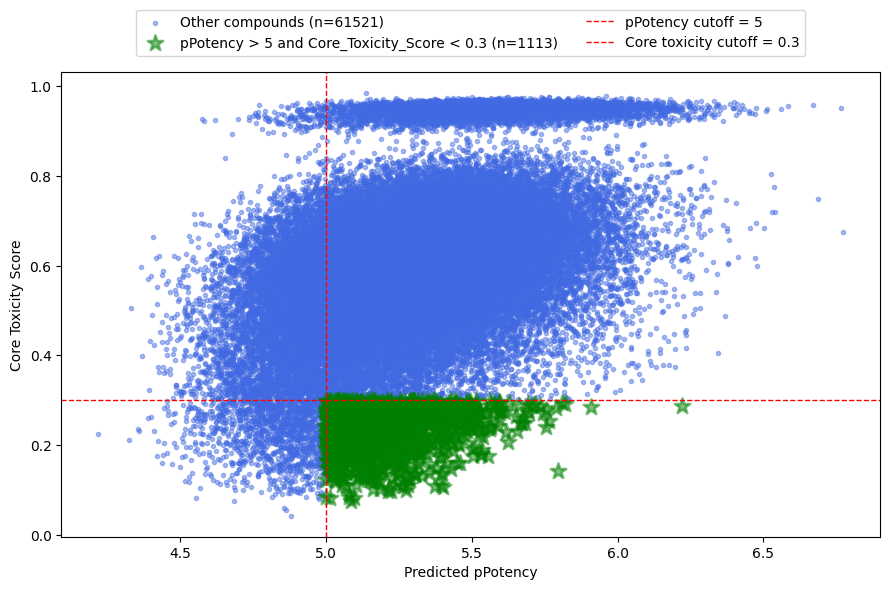

In [52]:
plotDF = combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity_sorted.copy()
highlightDF = combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity_core.copy()

# Rebuild mask from predefined cutoffs
highlightMask = (
    (plotDF["pPotency_prediction"] > pPotency_prediction_cutoff) &
    (plotDF["Core_Toxicity_Score"] < Core_Toxicity_cutoff)
)

backgroundDF = plotDF[~highlightMask]

otherCount = len(backgroundDF)
highlightCount = len(highlightDF)

plt.figure(figsize=(9, 6))

# Plot all other compounds
plt.scatter(
    backgroundDF["pPotency_prediction"],
    backgroundDF["Core_Toxicity_Score"],
    alpha=0.45,
    marker=".",
    c="royalblue",
    label=f"Other compounds (n={otherCount})"
)

# Plot filtered core compounds
plt.scatter(
    highlightDF["pPotency_prediction"],
    highlightDF["Core_Toxicity_Score"],
    alpha=0.5,
    marker="*",
    s=140,
    c="g",
    linewidths=1.8,
    label=f"pPotency > {pPotency_prediction_cutoff} and Core_Toxicity_Score < {Core_Toxicity_cutoff} (n={highlightCount})"
)

plt.axvline(
    x=pPotency_prediction_cutoff,
    c="r",
    linestyle="--",
    linewidth=1,
    label=f"pPotency cutoff = {pPotency_prediction_cutoff}"
)

plt.axhline(
    y=Core_Toxicity_cutoff,
    c="r",
    linestyle="--",
    linewidth=1,
    label=f"Core toxicity cutoff = {Core_Toxicity_cutoff}"
)

plt.xlabel("Predicted pPotency")
plt.ylabel("Core Toxicity Score")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=2)
plt.tight_layout()
plt.show()

### Create filtered dataframe with `Mechanistic_Alert_Score` & `ADME_Liability_Score`

In [53]:
# Select best overall compounds
combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity_allEndpoints = (
    combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity_sorted[
        (combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity_sorted["pPotency_prediction"] >= pPotency_prediction_cutoff) &
        (combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity_sorted["Core_Toxicity_Score"] < Core_Toxicity_cutoff) &
        (combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity_sorted["Mechanistic_Alert_Score"] < Mechanistic_Alert_cutoff) &
        (combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity_sorted["ADME_Liability_Score"] < ADME_Liability_cutoff)
    ]
    .copy()
)


combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity_allEndpoints.to_csv(resultsDir + 
                                                                           'combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity_allEndpoints.csv', index=False, encoding="utf-8")
combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity_allEndpoints

,SMILES,pPotency_prediction,pPotency_std,Core_Toxicity_Desirability,Core_Toxicity_Score,Mechanistic_Alert_Desirability,Mechanistic_Alert_Score,ADME_Desirability,ADME_Liability_Score,Safety_MPO_Desirability,Safety_MPO_RiskScore,Scoring_Method_Markdown


Total compounds: 62634
Best overall compounds: 0


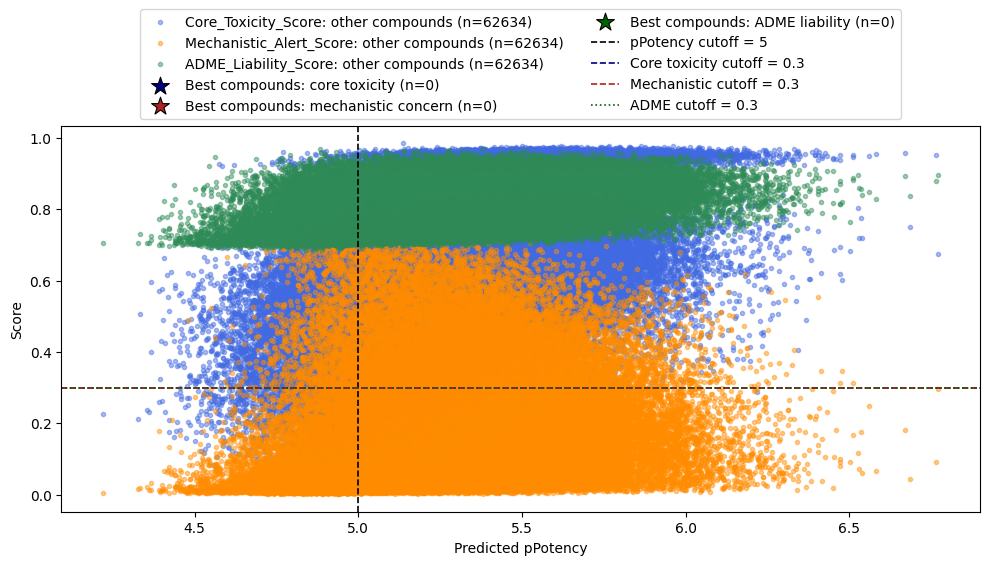

In [55]:
plotDF = combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity_sorted.copy()

highlightMask = (
    (plotDF["pPotency_prediction"] >= pPotency_prediction_cutoff) &
    (plotDF["Core_Toxicity_Score"] < Core_Toxicity_cutoff) &
    (plotDF["Mechanistic_Alert_Score"] < Mechanistic_Alert_cutoff) &
    (plotDF["ADME_Liability_Score"] < ADME_Liability_cutoff)
)

backgroundDF = plotDF[~highlightMask]
highlightDF = plotDF[highlightMask].copy()

otherCount = len(backgroundDF)
highlightCount = len(highlightDF)
totalCount = len(plotDF)

print("Total compounds:", totalCount)
print("Best overall compounds:", highlightCount)

plt.figure(figsize=(10, 6))

# Full distributions
plt.scatter(
    backgroundDF["pPotency_prediction"],
    backgroundDF["Core_Toxicity_Score"],
    alpha=0.45,
    marker=".",
    c="royalblue",
    label=f"Core_Toxicity_Score: other compounds (n={otherCount})"
)

plt.scatter(
    backgroundDF["pPotency_prediction"],
    backgroundDF["Mechanistic_Alert_Score"],
    alpha=0.45,
    marker=".",
    c="darkorange",
    label=f"Mechanistic_Alert_Score: other compounds (n={otherCount})"
)

plt.scatter(
    backgroundDF["pPotency_prediction"],
    backgroundDF["ADME_Liability_Score"],
    alpha=0.45,
    marker=".",
    c="seagreen",
    label=f"ADME_Liability_Score: other compounds (n={otherCount})"
)

# Highlight best compounds
plt.scatter(
    highlightDF["pPotency_prediction"],
    highlightDF["Core_Toxicity_Score"],
    alpha=1.0,
    marker="*",
    s=180,
    c="navy",
    edgecolors="black",
    linewidths=0.8,
    label=f"Best compounds: core toxicity (n={highlightCount})"
)

plt.scatter(
    highlightDF["pPotency_prediction"],
    highlightDF["Mechanistic_Alert_Score"],
    alpha=1.0,
    marker="*",
    s=180,
    c="firebrick",
    edgecolors="black",
    linewidths=0.8,
    label=f"Best compounds: mechanistic concern (n={highlightCount})"
)

plt.scatter(
    highlightDF["pPotency_prediction"],
    highlightDF["ADME_Liability_Score"],
    alpha=1.0,
    marker="*",
    s=180,
    c="darkgreen",
    edgecolors="black",
    linewidths=0.8,
    label=f"Best compounds: ADME liability (n={highlightCount})"
)

plt.axvline(
    x=pPotency_prediction_cutoff,
    c="black",
    linestyle="--",
    linewidth=1.2,
    label=f"pPotency cutoff = {pPotency_prediction_cutoff}"
)

plt.axhline(
    y=Core_Toxicity_cutoff,
    c="navy",
    linestyle="--",
    linewidth=1.2,
    label=f"Core toxicity cutoff = {Core_Toxicity_cutoff}"
)

plt.axhline(
    y=Mechanistic_Alert_cutoff,
    c="firebrick",
    linestyle="--",
    linewidth=1.2,
    label=f"Mechanistic cutoff = {Mechanistic_Alert_cutoff}"
)

plt.axhline(
    y=ADME_Liability_cutoff,
    c="darkgreen",
    linestyle=":",
    linewidth=1.2,
    label=f"ADME cutoff = {ADME_Liability_cutoff}"
)

plt.xlabel("Predicted pPotency")
plt.ylabel("Score")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.32), ncol=2)
plt.tight_layout()
plt.show()

## Check toxicty for `Inosibe + Adenosine + Guanosine + Xanthosine` DORANET generated AntiviralsData set

In [56]:
combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all = pd.read_csv(ARTresultsDir + 'Ebola_allDORAnetGenerated_Antivirals_ARTprediction.csv')
max_val = combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all['pPotency_prediction'].max()
min_val = combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all

pPotency_prediction range: 4.619 → 5.785


,SMILES,Is_Starter,SourceDirectories,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,True,InosineOnly_gen3,5.110976,0.607729,3.919828,6.302124,0.000008,4.987419e-07,0.000120
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,InosineOnly_gen3,5.412802,0.613704,4.209943,6.615661,0.000004,2.422918e-07,0.000062
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,InosineOnly_gen3,5.182013,0.608463,3.989425,6.374601,0.000007,4.220843e-07,0.000102
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,InosineOnly_gen3,5.668057,0.614157,4.464309,6.871804,0.000002,1.343370e-07,0.000034
4,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,InosineOnly_gen3,5.757816,0.613533,4.555292,6.960340,0.000002,1.095619e-07,0.000028
...,...,...,...,...,...,...,...,...,...,...
20367,NC(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c32...,False,XanthosineOnly_gen3,5.095807,0.608255,3.903627,6.287987,0.000008,5.152441e-07,0.000125
20368,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c3...,False,XanthosineOnly_gen3,5.004001,0.613899,3.800758,6.207243,0.000010,6.205213e-07,0.000158
20369,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c3...,False,XanthosineOnly_gen3,5.046440,0.612875,3.845205,6.247675,0.000009,5.653599e-07,0.000143
20370,CNC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c...,False,XanthosineOnly_gen3,5.079011,0.611216,3.881028,6.276994,0.000008,5.284525e-07,0.000132


### Read predicted ADMET properties for all candidate SMILES

In [57]:
combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity = pd.read_csv(ARTresultsDir + 'Ebola_allDORAnetGenerated_Antivirals_ARTprediction_wToxicity.csv')
max_val = combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity['pPotency_prediction'].max()
min_val = combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity

pPotency_prediction range: 4.619 → 5.785


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,logP,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,5.110976,0.607729,3.919828,6.302124,0.000008,4.987419e-07,0.000120,268.229,-2.26890,...,14.967041,41.954246,10.856921,46.413339,0.038775,28.034122,6.475378,9.965103,82.241179,24.156650
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,5.412802,0.613704,4.209943,6.615661,0.000004,2.422918e-07,0.000062,507.182,-1.62900,...,5.428461,23.381155,54.633579,87.398216,4.652966,9.112059,36.719659,28.887166,89.414502,9.732454
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,5.668057,0.614157,4.464309,6.871804,0.000002,1.343370e-07,0.000034,785.557,-2.42396,...,5.893757,12.563009,56.688639,69.910818,4.071345,53.392788,39.433889,46.219465,82.939124,2.326483
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,5.757816,0.613533,4.555292,6.960340,0.000002,1.095619e-07,0.000028,787.573,-1.75026,...,4.769290,15.936409,61.962001,83.365646,3.140752,61.186506,42.807290,44.784800,85.071733,7.134548
4,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,5.552294,0.610700,4.355322,6.749266,0.000003,1.781287e-07,0.000044,744.417,-2.89890,...,3.799922,19.542458,50.872431,92.904226,2.869329,13.803800,30.050407,24.505622,92.594029,16.401706
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7312,N#CC(O)(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[n...,4.973250,0.611276,3.775148,6.171351,0.000011,6.739823e-07,0.000168,350.247,-3.86964,...,13.028306,10.275301,5.273362,60.333463,0.775494,83.326871,12.252811,28.266770,70.065917,57.619232
7313,N#CC(O)(O)[C@H]1O[C@](C#N)(n2cnc3c(=O)[nH]c(=O...,5.029831,0.609572,3.835070,6.224592,0.000009,5.962222e-07,0.000146,350.247,-4.08564,...,15.238465,8.491663,3.450950,70.182241,1.008143,86.583947,12.214036,29.623885,66.731291,26.987204
7314,N#Cc1nc2c(=O)[nH]c(=O)[nH]c2n1[C@@H]1O[C@H](C(...,4.993202,0.610283,3.797047,6.189357,0.000010,6.466113e-07,0.000160,350.247,-3.89174,...,14.734393,12.252811,7.754944,65.335401,1.046917,80.961613,12.756883,29.274913,66.227220,36.060489
7315,O=C1NC2=NC(=O)[C@H]3O[C@H]([C@H](O)[C@@H]3O)n3...,5.228329,0.608842,4.035000,6.421659,0.000006,3.787402e-07,0.000092,279.212,-2.07580,...,18.611865,9.771229,11.709965,92.904226,0.038775,34.431950,8.801861,11.516092,65.568050,10.197751


### Retain potency predictions along with toxicity, mechanistic, and ADME-related endpoints

In [58]:
# Potency-related columns
potencyCols = [
    "SMILES",
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]

# Mechanistic alert endpoints
# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = potencyCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity.columns
]

combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity = combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity[selectedCols].copy()

print("Filtered dataframe shape:", combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity.shape)
combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity.head()

Filtered dataframe shape: (7317, 41)


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,AMES,hERG,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,5.110976,0.607729,3.919828,6.302124,0.000008,4.987419e-07,0.000120,0.591952,0.052745,...,0.016266,0.583451,0.001874,0.001193,0.083214,0.002164,0.012237,0.000492,0.048260,0.000058
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,5.412802,0.613704,4.209943,6.615661,0.000004,2.422918e-07,0.000062,0.033052,0.330824,...,0.024185,0.159878,0.001577,0.034541,0.056855,0.011661,0.015668,0.198030,0.076890,0.001108
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,5.668057,0.614157,4.464309,6.871804,0.000002,1.343370e-07,0.000034,0.239975,0.900458,...,0.070120,0.380114,0.007940,0.026014,0.047826,0.052646,0.026518,0.152412,0.267949,0.046004
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,5.757816,0.613533,4.555292,6.960340,0.000002,1.095619e-07,0.000028,0.188998,0.908109,...,0.050004,0.349236,0.005862,0.050689,0.057204,0.072706,0.040867,0.214760,0.236050,0.066886
4,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,5.552294,0.610700,4.355322,6.749266,0.000003,1.781287e-07,0.000044,0.160844,0.619006,...,0.033647,0.122790,0.001046,0.012560,0.021261,0.009916,0.009539,0.241743,0.165820,0.002698


### Filter compounds based on the results from Drugbank's `ADMET` summary

In [59]:
# ── Build range lookup dict from summary dataframe ─────────────────────────────
# Ensure Endpoint is the index and numeric types are correct
summaryDF = drugBankDrugData_approved_ADMET_summary.copy()

if "Endpoint" in summaryDF.columns:
    summaryDF = summaryDF.set_index("Endpoint")

summaryDF = summaryDF.astype(float)

rangeDict = summaryDF[["Min", "Max"]].to_dict(orient="index")

# ── Range mask builder ─────────────────────────────────────────────────────────
def buildRangeMask(df, endpointCols, rangeDict):
    """
    Returns a boolean Series: True if ALL available endpoints in endpointCols
    fall within [Min, Max] defined in rangeDict.
    Skips endpoints missing from either the dataframe or the rangeDict.
    """
    mask = pd.Series(True, index=df.index)
    skipped = []
    applied = []

    for col in endpointCols:
        if col not in df.columns or col not in rangeDict:
            skipped.append(col)
            continue
        colMin = rangeDict[col]["Min"]
        colMax = rangeDict[col]["Max"]
        mask = mask & df[col].between(colMin, colMax, inclusive="both")
        applied.append(col)

    return mask, applied, skipped


df = combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity.copy()
total = len(df)

# ── Apply masks per category ───────────────────────────────────────────────────
coreMask,        coreApplied,        coreSkipped        = buildRangeMask(df, coreToxicityCols,     rangeDict)
mechanisticMask, mechanisticApplied, mechanisticSkipped = buildRangeMask(df, mechanisticAlertCols, rangeDict)
admeMask,        admeApplied,        admeSkipped        = buildRangeMask(df, admeLiabilityCols,    rangeDict)

# Combined: must pass all three categories simultaneously
combinedMask = coreMask & mechanisticMask & admeMask

# ── Filter dataframes ──────────────────────────────────────────────────────────
df_coreFiltered        = df[coreMask].reset_index(drop=True)
df_mechanisticFiltered = df[mechanisticMask].reset_index(drop=True)
df_admeFiltered        = df[admeMask].reset_index(drop=True)
df_allFiltered         = df[combinedMask].reset_index(drop=True)

# ── Report 
print("         DrugBank Approved Range Filtering Summary")
print(f"Total input molecules: {total}")

print(f"\n──> Core Toxicity Endpoints ")
print(f"  Endpoints applied : {coreApplied}")
print(f"  Endpoints skipped : {coreSkipped}")
print(f"  Passing molecules : {len(df_coreFiltered)} / {total}  ({len(df_coreFiltered)/total*100:.2f}%)")

print(f"\n──> Mechanistic Alert Endpoints ")
print(f"  Endpoints applied : {mechanisticApplied}")
print(f"  Endpoints skipped : {mechanisticSkipped}")
print(f"  Passing molecules : {len(df_mechanisticFiltered)} / {total}  ({len(df_mechanisticFiltered)/total*100:.2f}%)")

print(f"\n──> ADME / Metabolism Liability Endpoints ")
print(f"  Endpoints applied : {admeApplied}")
print(f"  Endpoints skipped : {admeSkipped}")
print(f"  Passing molecules : {len(df_admeFiltered)} / {total}  ({len(df_admeFiltered)/total*100:.2f}%)")

print(f"\n──> Combined (ALL categories must pass) ")
print(f"  Passing molecules : {len(df_allFiltered)} / {total}  ({len(df_allFiltered)/total*100:.2f}%)")
print("=" * 65)

# ── Inspect results ────────────────────────────────────────────────────────────
print("\nCombined filtered dataframe shape:", df_allFiltered.shape)
combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity = df_allFiltered.copy()
combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity

         DrugBank Approved Range Filtering Summary
Total input molecules: 7317

──> Core Toxicity Endpoints 
  Endpoints applied : ['AMES', 'hERG', 'DILI', 'ClinTox', 'Carcinogens_Lagunin', 'Skin_Reaction', 'LD50_Zhu']
  Endpoints skipped : []
  Passing molecules : 7317 / 7317  (100.00%)

──> Mechanistic Alert Endpoints 
  Endpoints applied : ['SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53', 'NR-AR-LBD', 'NR-AR', 'NR-AhR', 'NR-Aromatase', 'NR-ER-LBD', 'NR-ER', 'NR-PPAR-gamma']
  Endpoints skipped : []
  Passing molecules : 7317 / 7317  (100.00%)

──> ADME / Metabolism Liability Endpoints 
  Endpoints applied : ['BBB_Martins', 'Pgp_Broccatelli', 'Caco2_Wang', 'HIA_Hou', 'PAMPA_NCATS', 'Bioavailability_Ma', 'CYP1A2_Veith', 'CYP2C19_Veith', 'CYP2C9_Substrate_CarbonMangels', 'CYP2C9_Veith', 'CYP2D6_Substrate_CarbonMangels', 'CYP2D6_Veith', 'CYP3A4_Substrate_CarbonMangels', 'CYP3A4_Veith']
  Endpoints skipped : []
  Passing molecules : 7317 / 7317  (100.00%)

──> Combined (ALL categories

,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,AMES,hERG,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,5.110976,0.607729,3.919828,6.302124,0.000008,4.987419e-07,0.000120,0.591952,0.052745,...,0.016266,0.583451,0.001874,0.001193,0.083214,0.002164,0.012237,0.000492,0.048260,0.000058
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,5.412802,0.613704,4.209943,6.615661,0.000004,2.422918e-07,0.000062,0.033052,0.330824,...,0.024185,0.159878,0.001577,0.034541,0.056855,0.011661,0.015668,0.198030,0.076890,0.001108
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,5.668057,0.614157,4.464309,6.871804,0.000002,1.343370e-07,0.000034,0.239975,0.900458,...,0.070120,0.380114,0.007940,0.026014,0.047826,0.052646,0.026518,0.152412,0.267949,0.046004
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,5.757816,0.613533,4.555292,6.960340,0.000002,1.095619e-07,0.000028,0.188998,0.908109,...,0.050004,0.349236,0.005862,0.050689,0.057204,0.072706,0.040867,0.214760,0.236050,0.066886
4,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,5.552294,0.610700,4.355322,6.749266,0.000003,1.781287e-07,0.000044,0.160844,0.619006,...,0.033647,0.122790,0.001046,0.012560,0.021261,0.009916,0.009539,0.241743,0.165820,0.002698
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7312,N#CC(O)(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[n...,4.973250,0.611276,3.775148,6.171351,0.000011,6.739823e-07,0.000168,0.309583,0.230926,...,0.018726,0.497215,0.002240,0.002667,0.085590,0.008185,0.014086,0.001790,0.104031,0.000361
7313,N#CC(O)(O)[C@H]1O[C@](C#N)(n2cnc3c(=O)[nH]c(=O...,5.029831,0.609572,3.835070,6.224592,0.000009,5.962222e-07,0.000146,0.299855,0.240588,...,0.019837,0.549262,0.002167,0.002572,0.097613,0.006948,0.014348,0.000939,0.101619,0.000256
7314,N#Cc1nc2c(=O)[nH]c(=O)[nH]c2n1[C@@H]1O[C@H](C(...,4.993202,0.610283,3.797047,6.189357,0.000010,6.466113e-07,0.000160,0.348871,0.405404,...,0.029763,0.527066,0.007756,0.006163,0.090708,0.014822,0.016534,0.002756,0.103617,0.000452
7315,O=C1NC2=NC(=O)[C@H]3O[C@H]([C@H](O)[C@@H]3O)n3...,5.228329,0.608842,4.035000,6.421659,0.000006,3.787402e-07,0.000092,0.627843,0.120417,...,0.062822,0.696781,0.015795,0.003920,0.154343,0.004839,0.011613,0.003596,0.069156,0.000079


### Multiparameter optimization (MPO) framework based ADMET scoring

We replaced simple arithmetic averaging with a weighted desirability-based multiparameter optimization (MPO) framework. Each ADMET endpoint was converted to a 0–1 desirability value, where `1 --> favorable` and `0 --> unfavorable` profile. Category-level scores were then combined using weighted geometric means, following the same general pattern used in QED and ADMET-score approaches.

**References**

1. ADMET-score – a comprehensive scoring function for evaluation of chemical drug-likeness (https://pubs.rsc.org/en/content/articlelanding/2019/md/c8md00472b)
2. Quantifying the chemical beauty of drugs (https://www.nature.com/articles/nchem.1243)

In [60]:
df = combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity.copy()


# Endpoint groups
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu",
]

mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma",
]

# Define these lists according to how you want to treat directionality
# lower-is-better => toxicity/liability style probabilities
admeLowerIsBetter = [
    "Pgp_Broccatelli",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith",
]

# higher-is-better => absorption / permeability / bioavailability style endpoints
admeHigherIsBetter = [
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
]

# Optional / context-dependent endpoint
# For non-CNS antivirals, you may wish to penalize BBB penetration.
# For CNS programs, you may want the opposite or exclude it from the score.
includeBBB = False
if includeBBB and "BBB_Martins" in df.columns:
    admeLowerIsBetter = admeLowerIsBetter + ["BBB_Martins"]


# Utilities
epsilon = 1e-6

def clip01(series):
    return series.clip(lower=epsilon, upper=1 - epsilon)

def desirabilityFromRiskProbability(series):
    """
    For toxicity/liability probabilities:
    lower risk is better -> desirability = 1 - p
    """
    return clip01(1 - series)

def desirabilityFromBenefitProbability(series):
    """
    For favorable probabilities/scores already in [0,1]:
    higher is better -> desirability = p
    """
    return clip01(series)

def desirabilityFromLD50(series, lowerQuantile=0.10, upperQuantile=0.90):
    """
    LD50_Zhu is treated as a regression-style acute toxicity endpoint.
    Higher LD50_Zhu implies greater acute toxicity risk.
    Map lower values -> high desirability, higher values -> low desirability.

    Uses a robust percentile-based linear desirability transform so the score
    is less sensitive to extreme outliers than plain min-max scaling.
    """
    qLow = series.quantile(lowerQuantile)
    qHigh = series.quantile(upperQuantile)

    if pd.isna(qLow) or pd.isna(qHigh) or qHigh == qLow:
        return pd.Series(0.5, index=series.index)

    # lower LD50_Zhu = better, higher = worse
    desirability = 1 - ((series - qLow) / (qHigh - qLow))
    return clip01(desirability)

def weightedGeometricMean(dfValues, weightsDict):
    """
    Compute weighted geometric mean across available columns only.
    """
    availableCols = [col for col in weightsDict if col in dfValues.columns]
    if len(availableCols) == 0:
        return pd.Series(np.nan, index=dfValues.index)

    weights = np.array([weightsDict[col] for col in availableCols], dtype=float)
    weights = weights / weights.sum()

    values = dfValues[availableCols].copy()
    values = values.clip(lower=epsilon, upper=1 - epsilon)

    logWeighted = np.log(values).mul(weights, axis=1).sum(axis=1)
    return np.exp(logWeighted)

# -----------------------------------------------------------------------------
# 1. Core toxicity desirability
# -----------------------------------------------------------------------------
coreWeights = {
    "AMES": 1.0,
    "hERG": 1.5,
    "DILI": 1.5,
    "ClinTox": 1.5,
    "Carcinogens_Lagunin": 1.0,
    "Skin_Reaction": 0.5,
    "LD50_Zhu": 1.25,
}

coreDesirabilityDF = pd.DataFrame(index=df.index)

for colName in coreToxicityCols:
    if colName not in df.columns:
        continue

    if colName == "LD50_Zhu":
        coreDesirabilityDF[colName] = desirabilityFromLD50(df[colName])
    else:
        coreDesirabilityDF[colName] = desirabilityFromRiskProbability(df[colName])

df["Core_Toxicity_Desirability"] = weightedGeometricMean(coreDesirabilityDF, coreWeights)

# Optional inverse form if you want "higher = worse"
df["Core_Toxicity_Score"] = 1 - df["Core_Toxicity_Desirability"]

# -----------------------------------------------------------------------------
# 2. Mechanistic alert desirability
# -----------------------------------------------------------------------------
mechWeights = {
    "SR-ARE": 1.0,
    "SR-ATAD5": 1.0,
    "SR-HSE": 0.75,
    "SR-MMP": 1.25,
    "SR-p53": 1.0,
    "NR-AR-LBD": 0.75,
    "NR-AR": 0.75,
    "NR-AhR": 0.75,
    "NR-Aromatase": 0.75,
    "NR-ER-LBD": 0.75,
    "NR-ER": 0.75,
    "NR-PPAR-gamma": 0.5,
}

mechDesirabilityDF = pd.DataFrame(index=df.index)
for colName in mechanisticAlertCols:
    if colName in df.columns:
        mechDesirabilityDF[colName] = desirabilityFromRiskProbability(df[colName])

df["Mechanistic_Alert_Desirability"] = weightedGeometricMean(mechDesirabilityDF, mechWeights)
df["Mechanistic_Alert_Score"] = 1 - df["Mechanistic_Alert_Desirability"]

# -----------------------------------------------------------------------------
# 3. ADME liability desirability
# -----------------------------------------------------------------------------
admeWeights = {
    "BBB_Martins": 0.5,   # context dependent
    "Pgp_Broccatelli": 1.0,
    "Caco2_Wang": 1.0,
    "HIA_Hou": 1.0,
    "PAMPA_NCATS": 0.75,
    "Bioavailability_Ma": 1.25,
    "CYP1A2_Veith": 1.0,
    "CYP2C19_Veith": 1.0,
    "CYP2C9_Substrate_CarbonMangels": 0.75,
    "CYP2C9_Veith": 1.0,
    "CYP2D6_Substrate_CarbonMangels": 0.75,
    "CYP2D6_Veith": 1.0,
    "CYP3A4_Substrate_CarbonMangels": 0.75,
    "CYP3A4_Veith": 1.0,
}

admeDesirabilityDF = pd.DataFrame(index=df.index)

for colName in admeLowerIsBetter:
    if colName in df.columns:
        admeDesirabilityDF[colName] = desirabilityFromRiskProbability(df[colName])

for colName in admeHigherIsBetter:
    if colName in df.columns:
        admeDesirabilityDF[colName] = desirabilityFromBenefitProbability(df[colName])

df["ADME_Desirability"] = weightedGeometricMean(admeDesirabilityDF, admeWeights)
df["ADME_Liability_Score"] = 1 - df["ADME_Desirability"]

# -----------------------------------------------------------------------------
# 4. Final MPO-style safety score
# -----------------------------------------------------------------------------
# Higher desirability = better
# We give core toxicity the highest influence, then ADME, then mechanistic alerts.
componentDesirabilityDF = pd.DataFrame({
    "Core_Toxicity_Desirability": df["Core_Toxicity_Desirability"],
    "Mechanistic_Alert_Desirability": df["Mechanistic_Alert_Desirability"],
    "ADME_Desirability": df["ADME_Desirability"],
})

componentWeights = {
    "Core_Toxicity_Desirability": 0.50,
    "Mechanistic_Alert_Desirability": 0.20,
    "ADME_Desirability": 0.30,
}

df["Safety_MPO_Desirability"] = weightedGeometricMean(
    componentDesirabilityDF,
    componentWeights
)

# Optional inverse form if you want higher = worse
df["Safety_MPO_RiskScore"] = 1 - df["Safety_MPO_Desirability"]

# -----------------------------------------------------------------------------
# 5. Markdown-style explanation column
# -----------------------------------------------------------------------------
markdownNote = (
    "Composite scores were computed using a weighted desirability-based MPO framework. "
    "Each endpoint was transformed to a 0–1 desirability value, then combined with a "
    "weighted geometric mean. Core toxicity used AMES, hERG, DILI, ClinTox, "
    "Carcinogens_Lagunin, Skin_Reaction, and LD50_Zhu; mechanistic score used SR/NR "
    "alerts; ADME score used direction-adjusted absorption, transporter, and CYP endpoints. "
    "This follows the general scoring pattern used in QED and ADMET-score literature."
)

df["Scoring_Method_Markdown"] = markdownNote

# -----------------------------------------------------------------------------
# 6. Final output
# -----------------------------------------------------------------------------
combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_sorted = df[
    [
        "SMILES",
        "pPotency_prediction",
        "pPotency_std",
        "Core_Toxicity_Desirability",
        "Core_Toxicity_Score",
        "Mechanistic_Alert_Desirability",
        "Mechanistic_Alert_Score",
        "ADME_Desirability",
        "ADME_Liability_Score",
        "Safety_MPO_Desirability",
        "Safety_MPO_RiskScore",
        "Scoring_Method_Markdown",
    ]
].copy()

combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_sorted

,SMILES,pPotency_prediction,pPotency_std,Core_Toxicity_Desirability,Core_Toxicity_Score,Mechanistic_Alert_Desirability,Mechanistic_Alert_Score,ADME_Desirability,ADME_Liability_Score,Safety_MPO_Desirability,Safety_MPO_RiskScore,Scoring_Method_Markdown
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,5.110976,0.607729,0.441340,0.558660,0.916237,0.083763,0.226717,0.773283,0.418247,0.581753,Composite scores were computed using a weighte...
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,5.412802,0.613704,0.665276,0.334724,0.959302,0.040698,0.152200,0.847800,0.459850,0.540150,Composite scores were computed using a weighte...
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,5.668057,0.614157,0.251946,0.748054,0.886391,0.113609,0.204777,0.795223,0.304483,0.695517,Composite scores were computed using a weighte...
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,5.757816,0.613533,0.044426,0.955574,0.914057,0.085943,0.194188,0.805812,0.126614,0.873386,Composite scores were computed using a weighte...
4,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,5.552294,0.610700,0.637516,0.362484,0.937107,0.062893,0.143793,0.856207,0.440479,0.559521,Composite scores were computed using a weighte...
...,...,...,...,...,...,...,...,...,...,...,...,...
7312,N#CC(O)(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[n...,4.973250,0.611276,0.054747,0.945253,0.938808,0.061192,0.209664,0.790336,0.144595,0.855405,Composite scores were computed using a weighte...
7313,N#CC(O)(O)[C@H]1O[C@](C#N)(n2cnc3c(=O)[nH]c(=O...,5.029831,0.609572,0.054678,0.945322,0.939855,0.060145,0.213785,0.786215,0.145382,0.854618,Composite scores were computed using a weighte...
7314,N#Cc1nc2c(=O)[nH]c(=O)[nH]c2n1[C@@H]1O[C@H](C(...,4.993202,0.610283,0.047616,0.952384,0.890717,0.109283,0.213373,0.786627,0.134143,0.865857,Composite scores were computed using a weighte...
7315,O=C1NC2=NC(=O)[C@H]3O[C@H]([C@H](O)[C@@H]3O)n3...,5.228329,0.608842,0.391868,0.608132,0.870998,0.129002,0.256014,0.743986,0.404625,0.595375,Composite scores were computed using a weighte...


### Define filter for compound ranking based on `ADMET` scores

In [61]:
pPotency_prediction_cutoff = 5
Core_Toxicity_cutoff = 0.3
Mechanistic_Alert_cutoff = 0.3
ADME_Liability_cutoff = 0.3

In [62]:
combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_core = (
    combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_sorted[
        (combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_sorted["pPotency_prediction"] > pPotency_prediction_cutoff) &
        (combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_sorted["Core_Toxicity_Score"] < Core_Toxicity_cutoff)
    ]
    .reset_index(drop=True)
)


combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_core.to_csv(resultsDir + 
                                                                           'combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_nonToxic_core.csv', index=False, encoding="utf-8")
combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_core

### Plot full distribution + highlighted filtered dataframe

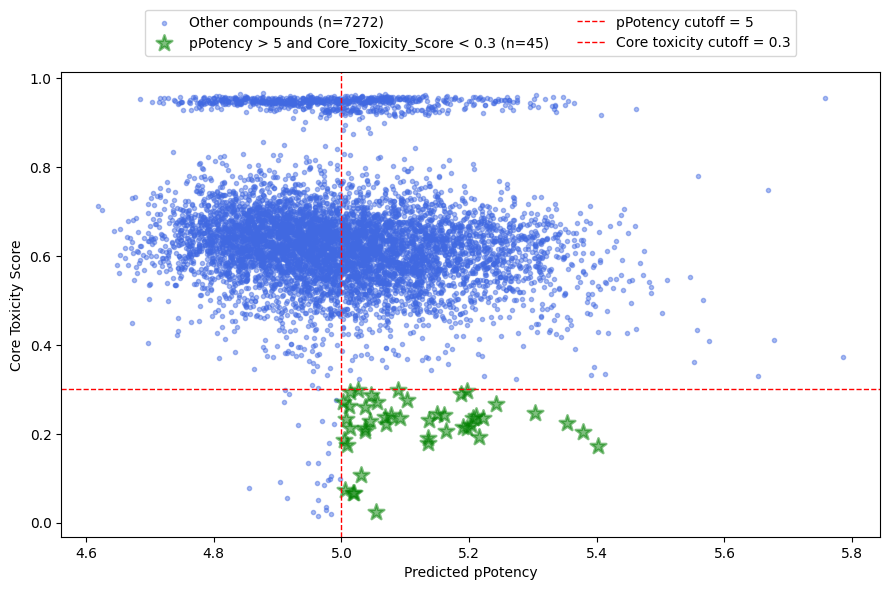

In [64]:
plotDF = combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_sorted.copy()
highlightDF = combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_core.copy()

# Rebuild mask from predefined cutoffs
highlightMask = (
    (plotDF["pPotency_prediction"] > pPotency_prediction_cutoff) &
    (plotDF["Core_Toxicity_Score"] < Core_Toxicity_cutoff)
)

backgroundDF = plotDF[~highlightMask]

otherCount = len(backgroundDF)
highlightCount = len(highlightDF)

plt.figure(figsize=(9, 6))

# Plot all other compounds
plt.scatter(
    backgroundDF["pPotency_prediction"],
    backgroundDF["Core_Toxicity_Score"],
    alpha=0.45,
    marker=".",
    c="royalblue",
    label=f"Other compounds (n={otherCount})"
)

# Plot filtered core compounds
plt.scatter(
    highlightDF["pPotency_prediction"],
    highlightDF["Core_Toxicity_Score"],
    alpha=0.5,
    marker="*",
    s=140,
    c="g",
    linewidths=1.8,
    label=f"pPotency > {pPotency_prediction_cutoff} and Core_Toxicity_Score < {Core_Toxicity_cutoff} (n={highlightCount})"
)

plt.axvline(
    x=pPotency_prediction_cutoff,
    c="r",
    linestyle="--",
    linewidth=1,
    label=f"pPotency cutoff = {pPotency_prediction_cutoff}"
)

plt.axhline(
    y=Core_Toxicity_cutoff,
    c="r",
    linestyle="--",
    linewidth=1,
    label=f"Core toxicity cutoff = {Core_Toxicity_cutoff}"
)

plt.xlabel("Predicted pPotency")
plt.ylabel("Core Toxicity Score")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=2)
plt.tight_layout()
plt.show()

### Create filtered dataframe with `Mechanistic_Alert_Score` & `ADME_Liability_Score`

In [65]:
# Select best overall compounds
combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_allEndpoints = (
    combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_sorted[
        (combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_sorted["pPotency_prediction"] >= pPotency_prediction_cutoff) &
        (combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_sorted["Core_Toxicity_Score"] < Core_Toxicity_cutoff) &
        (combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_sorted["Mechanistic_Alert_Score"] < Mechanistic_Alert_cutoff) &
        (combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_sorted["ADME_Liability_Score"] < ADME_Liability_cutoff)
    ]
    .copy()
)


combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_allEndpoints.to_csv(resultsDir + 
                                                                           'combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_allEndpoints.csv', index=False, encoding="utf-8")
combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_allEndpoints

,SMILES,pPotency_prediction,pPotency_std,Core_Toxicity_Desirability,Core_Toxicity_Score,Mechanistic_Alert_Desirability,Mechanistic_Alert_Score,ADME_Desirability,ADME_Liability_Score,Safety_MPO_Desirability,Safety_MPO_RiskScore,Scoring_Method_Markdown


Total compounds: 7317
Best overall compounds: 0


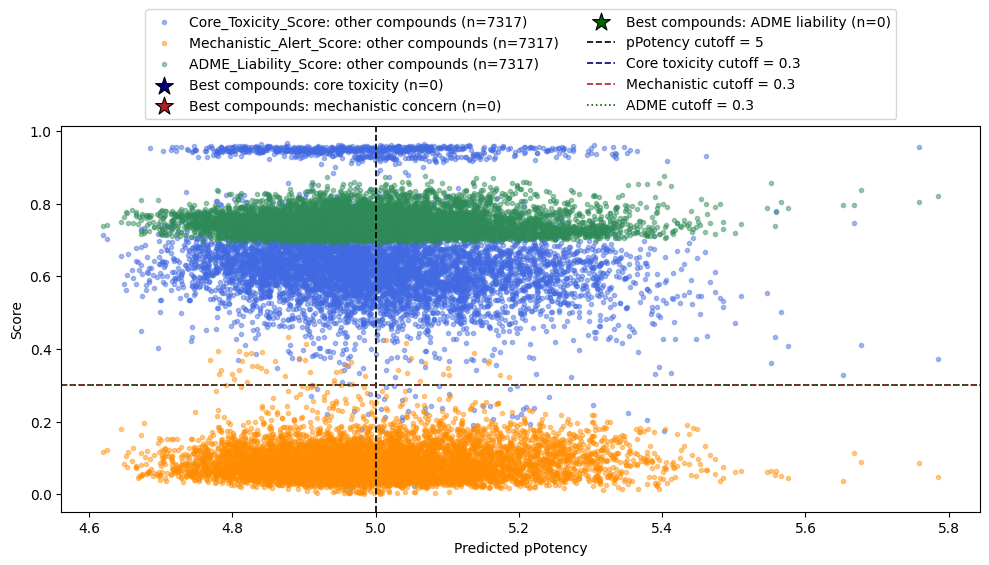

In [66]:
plotDF = combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_sorted.copy()

highlightMask = (
    (plotDF["pPotency_prediction"] >= pPotency_prediction_cutoff) &
    (plotDF["Core_Toxicity_Score"] < Core_Toxicity_cutoff) &
    (plotDF["Mechanistic_Alert_Score"] < Mechanistic_Alert_cutoff) &
    (plotDF["ADME_Liability_Score"] < ADME_Liability_cutoff)
)

backgroundDF = plotDF[~highlightMask]
highlightDF = plotDF[highlightMask].copy()

otherCount = len(backgroundDF)
highlightCount = len(highlightDF)
totalCount = len(plotDF)

print("Total compounds:", totalCount)
print("Best overall compounds:", highlightCount)

plt.figure(figsize=(10, 6))

# Full distributions
plt.scatter(
    backgroundDF["pPotency_prediction"],
    backgroundDF["Core_Toxicity_Score"],
    alpha=0.45,
    marker=".",
    c="royalblue",
    label=f"Core_Toxicity_Score: other compounds (n={otherCount})"
)

plt.scatter(
    backgroundDF["pPotency_prediction"],
    backgroundDF["Mechanistic_Alert_Score"],
    alpha=0.45,
    marker=".",
    c="darkorange",
    label=f"Mechanistic_Alert_Score: other compounds (n={otherCount})"
)

plt.scatter(
    backgroundDF["pPotency_prediction"],
    backgroundDF["ADME_Liability_Score"],
    alpha=0.45,
    marker=".",
    c="seagreen",
    label=f"ADME_Liability_Score: other compounds (n={otherCount})"
)

# Highlight best compounds
plt.scatter(
    highlightDF["pPotency_prediction"],
    highlightDF["Core_Toxicity_Score"],
    alpha=1.0,
    marker="*",
    s=180,
    c="navy",
    edgecolors="black",
    linewidths=0.8,
    label=f"Best compounds: core toxicity (n={highlightCount})"
)

plt.scatter(
    highlightDF["pPotency_prediction"],
    highlightDF["Mechanistic_Alert_Score"],
    alpha=1.0,
    marker="*",
    s=180,
    c="firebrick",
    edgecolors="black",
    linewidths=0.8,
    label=f"Best compounds: mechanistic concern (n={highlightCount})"
)

plt.scatter(
    highlightDF["pPotency_prediction"],
    highlightDF["ADME_Liability_Score"],
    alpha=1.0,
    marker="*",
    s=180,
    c="darkgreen",
    edgecolors="black",
    linewidths=0.8,
    label=f"Best compounds: ADME liability (n={highlightCount})"
)

plt.axvline(
    x=pPotency_prediction_cutoff,
    c="black",
    linestyle="--",
    linewidth=1.2,
    label=f"pPotency cutoff = {pPotency_prediction_cutoff}"
)

plt.axhline(
    y=Core_Toxicity_cutoff,
    c="navy",
    linestyle="--",
    linewidth=1.2,
    label=f"Core toxicity cutoff = {Core_Toxicity_cutoff}"
)

plt.axhline(
    y=Mechanistic_Alert_cutoff,
    c="firebrick",
    linestyle="--",
    linewidth=1.2,
    label=f"Mechanistic cutoff = {Mechanistic_Alert_cutoff}"
)

plt.axhline(
    y=ADME_Liability_cutoff,
    c="darkgreen",
    linestyle=":",
    linewidth=1.2,
    label=f"ADME cutoff = {ADME_Liability_cutoff}"
)

plt.xlabel("Predicted pPotency")
plt.ylabel("Score")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.32), ncol=2)
plt.tight_layout()
plt.show()

## Check toxicty for `Inosine-substructures` DORANET generated AntiviralsData set

In [67]:
combinedEbolaVirus_wART_InosineSubstructures_predicted_all = pd.read_csv(ARTresultsDir + 'combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_ARTprediction.csv')
max_val = combinedEbolaVirus_wART_InosineSubstructures_predicted_all['pPotency_prediction'].max()
min_val = combinedEbolaVirus_wART_InosineSubstructures_predicted_all['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
combinedEbolaVirus_wART_InosineSubstructures_predicted_all

pPotency_prediction range: 4.702 → 6.048


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,5.412802,0.613704,4.209943,6.615661,0.000004,2.422918e-07,0.000062
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,5.182013,0.608463,3.989425,6.374601,0.000007,4.220843e-07,0.000102
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,5.668057,0.614157,4.464309,6.871804,0.000002,1.343370e-07,0.000034
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,5.757816,0.613533,4.555292,6.960340,0.000002,1.095619e-07,0.000028
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,5.330797,0.610017,4.135163,6.526430,0.000005,2.975568e-07,0.000073
...,...,...,...,...,...,...,...,...
20875,O=C1Oc2nc3c(c(=O)[nH]2)n1c[n+]3[C@@H]1O[C@H](C...,5.141413,0.607802,3.950120,6.332705,0.000007,4.648310e-07,0.000112
20876,O=C(O)n1c[n+]([C@@H]2O[C@H](C(O)O)[C@@H](O)[C@...,5.249452,0.607519,4.058715,6.440190,0.000006,3.629195e-07,0.000087
20877,N#CC(O)(O)[C@H]1O[C@@H]([n+]2cn(C(=O)O)c3c(=O)...,5.173319,0.609265,3.979158,6.367479,0.000007,4.290632e-07,0.000105
20878,NC(=O)[C@H]1O[C@@H]([n+]2cn(C(=O)O)c3c(=O)[nH]...,5.145128,0.610115,3.949303,6.340952,0.000007,4.560870e-07,0.000112


### Read predicted ADMET properties for all candidate SMILES

In [68]:
combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity = pd.read_csv(ARTresultsDir + 'combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_ARTprediction_wToxicity.csv')
max_val = combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity['pPotency_prediction'].max()
min_val = combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity

pPotency_prediction range: 4.702 → 6.048


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,logP,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,5.412802,0.613704,4.209943,6.615661,0.000004,2.422918e-07,0.000062,507.182,-1.62900,...,5.428461,23.381155,54.633579,87.398216,4.652966,9.112059,36.719659,28.887166,89.414502,9.732454
1,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,5.668057,0.614157,4.464309,6.871804,0.000002,1.343370e-07,0.000034,785.557,-2.42396,...,5.893757,12.563009,56.688639,69.910818,4.071345,53.392788,39.433889,46.219465,82.939124,2.326483
2,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,5.757816,0.613533,4.555292,6.960340,0.000002,1.095619e-07,0.000028,787.573,-1.75026,...,4.769290,15.936409,61.962001,83.365646,3.140752,61.186506,42.807290,44.784800,85.071733,7.134548
3,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,5.552294,0.610700,4.355322,6.749266,0.000003,1.781287e-07,0.000044,744.417,-2.89890,...,3.799922,19.542458,50.872431,92.904226,2.869329,13.803800,30.050407,24.505622,92.594029,16.401706
4,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,5.677128,0.612279,4.477060,6.877195,0.000002,1.326798e-07,0.000033,745.425,-2.56940,...,4.226444,29.701435,76.075998,88.096161,3.722373,29.352462,35.944164,27.142303,91.081815,2.791780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3230,O=C1Oc2n1c1c(=O)[nH]cnc1[n+]2[C@@H]1O[C@H](C(O...,5.147525,0.608119,3.955612,6.339437,0.000007,4.576807e-07,0.000111,327.229,-3.69750,...,19.503684,22.915859,3.373401,53.354013,1.008143,47.925553,6.863125,21.946491,74.486235,53.005041
3231,O=C(O)n1c[n+]2c3nc([nH]c(=O)c31)O[C@@H]1[C@H](...,5.100356,0.609073,3.906574,6.294139,0.000008,5.079968e-07,0.000124,327.229,-3.13180,...,12.834432,14.850717,3.101978,47.809228,1.046917,34.625824,2.055060,21.675068,72.974021,47.460256
3232,O=C1Oc2nc3c(c(=O)[nH]2)n1c[n+]3[C@@H]1O[C@H](C...,5.141413,0.607802,3.950120,6.332705,0.000007,4.648310e-07,0.000112,327.229,-3.69750,...,18.611865,25.901512,5.506010,60.953858,0.387747,59.131446,7.948817,22.915859,72.043428,49.205118
3233,O=C(O)n1c[n+]([C@@H]2O[C@H](C(O)O)[C@@H](O)[C@...,5.249452,0.607519,4.058715,6.440190,0.000006,3.629195e-07,0.000087,329.245,-3.53190,...,9.538581,32.221791,7.056999,53.198914,0.155099,22.295463,2.055060,13.726250,78.208608,67.661884


### Retain potency predictions along with toxicity, mechanistic, and ADME-related endpoints

In [69]:
# Potency-related columns
potencyCols = [
    "SMILES",
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]

# Mechanistic alert endpoints
# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = potencyCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity.columns
]

combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity = combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity[selectedCols].copy()

print("Filtered dataframe shape:", combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity.shape)
combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity.head()

Filtered dataframe shape: (3235, 41)


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,AMES,hERG,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,5.412802,0.613704,4.209943,6.615661,0.000004,2.422918e-07,0.000062,0.033052,0.330824,...,0.024185,0.159878,0.001577,0.034541,0.056855,0.011661,0.015668,0.198030,0.076890,0.001108
1,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,5.668057,0.614157,4.464309,6.871804,0.000002,1.343370e-07,0.000034,0.239975,0.900458,...,0.070120,0.380114,0.007940,0.026014,0.047826,0.052646,0.026518,0.152412,0.267949,0.046004
2,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,5.757816,0.613533,4.555292,6.960340,0.000002,1.095619e-07,0.000028,0.188998,0.908109,...,0.050004,0.349236,0.005862,0.050689,0.057204,0.072706,0.040867,0.214760,0.236050,0.066886
3,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,5.552294,0.610700,4.355322,6.749266,0.000003,1.781287e-07,0.000044,0.160844,0.619006,...,0.033647,0.122790,0.001046,0.012560,0.021261,0.009916,0.009539,0.241743,0.165820,0.002698
4,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,5.677128,0.612279,4.477060,6.877195,0.000002,1.326798e-07,0.000033,0.198825,0.550806,...,0.056442,0.123578,0.001490,0.031071,0.019455,0.017940,0.009144,0.228861,0.219715,0.009885


### Filter compounds based on the results from Drugbank's `ADMET` summary

In [70]:
# ── Build range lookup dict from summary dataframe ─────────────────────────────
# Ensure Endpoint is the index and numeric types are correct
summaryDF = drugBankDrugData_approved_ADMET_summary.copy()

if "Endpoint" in summaryDF.columns:
    summaryDF = summaryDF.set_index("Endpoint")

summaryDF = summaryDF.astype(float)

rangeDict = summaryDF[["Min", "Max"]].to_dict(orient="index")

# ── Range mask builder ─────────────────────────────────────────────────────────
def buildRangeMask(df, endpointCols, rangeDict):
    """
    Returns a boolean Series: True if ALL available endpoints in endpointCols
    fall within [Min, Max] defined in rangeDict.
    Skips endpoints missing from either the dataframe or the rangeDict.
    """
    mask = pd.Series(True, index=df.index)
    skipped = []
    applied = []

    for col in endpointCols:
        if col not in df.columns or col not in rangeDict:
            skipped.append(col)
            continue
        colMin = rangeDict[col]["Min"]
        colMax = rangeDict[col]["Max"]
        mask = mask & df[col].between(colMin, colMax, inclusive="both")
        applied.append(col)

    return mask, applied, skipped


df = combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity.copy()
total = len(df)

# ── Apply masks per category ───────────────────────────────────────────────────
coreMask,        coreApplied,        coreSkipped        = buildRangeMask(df, coreToxicityCols,     rangeDict)
mechanisticMask, mechanisticApplied, mechanisticSkipped = buildRangeMask(df, mechanisticAlertCols, rangeDict)
admeMask,        admeApplied,        admeSkipped        = buildRangeMask(df, admeLiabilityCols,    rangeDict)

# Combined: must pass all three categories simultaneously
combinedMask = coreMask & mechanisticMask & admeMask

# ── Filter dataframes ──────────────────────────────────────────────────────────
df_coreFiltered        = df[coreMask].reset_index(drop=True)
df_mechanisticFiltered = df[mechanisticMask].reset_index(drop=True)
df_admeFiltered        = df[admeMask].reset_index(drop=True)
df_allFiltered         = df[combinedMask].reset_index(drop=True)

# ── Report 
print("         DrugBank Approved Range Filtering Summary")
print(f"Total input molecules: {total}")

print(f"\n──> Core Toxicity Endpoints ")
print(f"  Endpoints applied : {coreApplied}")
print(f"  Endpoints skipped : {coreSkipped}")
print(f"  Passing molecules : {len(df_coreFiltered)} / {total}  ({len(df_coreFiltered)/total*100:.2f}%)")

print(f"\n──> Mechanistic Alert Endpoints ")
print(f"  Endpoints applied : {mechanisticApplied}")
print(f"  Endpoints skipped : {mechanisticSkipped}")
print(f"  Passing molecules : {len(df_mechanisticFiltered)} / {total}  ({len(df_mechanisticFiltered)/total*100:.2f}%)")

print(f"\n──> ADME / Metabolism Liability Endpoints ")
print(f"  Endpoints applied : {admeApplied}")
print(f"  Endpoints skipped : {admeSkipped}")
print(f"  Passing molecules : {len(df_admeFiltered)} / {total}  ({len(df_admeFiltered)/total*100:.2f}%)")

print(f"\n──> Combined (ALL categories must pass) ")
print(f"  Passing molecules : {len(df_allFiltered)} / {total}  ({len(df_allFiltered)/total*100:.2f}%)")
print("=" * 65)

# ── Inspect results ────────────────────────────────────────────────────────────
print("\nCombined filtered dataframe shape:", df_allFiltered.shape)
combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity = df_allFiltered.copy()
combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity

         DrugBank Approved Range Filtering Summary
Total input molecules: 3235

──> Core Toxicity Endpoints 
  Endpoints applied : ['AMES', 'hERG', 'DILI', 'ClinTox', 'Carcinogens_Lagunin', 'Skin_Reaction', 'LD50_Zhu']
  Endpoints skipped : []
  Passing molecules : 3228 / 3235  (99.78%)

──> Mechanistic Alert Endpoints 
  Endpoints applied : ['SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53', 'NR-AR-LBD', 'NR-AR', 'NR-AhR', 'NR-Aromatase', 'NR-ER-LBD', 'NR-ER', 'NR-PPAR-gamma']
  Endpoints skipped : []
  Passing molecules : 3235 / 3235  (100.00%)

──> ADME / Metabolism Liability Endpoints 
  Endpoints applied : ['BBB_Martins', 'Pgp_Broccatelli', 'Caco2_Wang', 'HIA_Hou', 'PAMPA_NCATS', 'Bioavailability_Ma', 'CYP1A2_Veith', 'CYP2C19_Veith', 'CYP2C9_Substrate_CarbonMangels', 'CYP2C9_Veith', 'CYP2D6_Substrate_CarbonMangels', 'CYP2D6_Veith', 'CYP3A4_Substrate_CarbonMangels', 'CYP3A4_Veith']
  Endpoints skipped : []
  Passing molecules : 3231 / 3235  (99.88%)

──> Combined (ALL categories m

,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,AMES,hERG,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,5.412802,0.613704,4.209943,6.615661,0.000004,2.422918e-07,0.000062,0.033052,0.330824,...,0.024185,0.159878,0.001577,0.034541,0.056855,0.011661,0.015668,0.198030,0.076890,0.001108
1,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,5.668057,0.614157,4.464309,6.871804,0.000002,1.343370e-07,0.000034,0.239975,0.900458,...,0.070120,0.380114,0.007940,0.026014,0.047826,0.052646,0.026518,0.152412,0.267949,0.046004
2,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,5.757816,0.613533,4.555292,6.960340,0.000002,1.095619e-07,0.000028,0.188998,0.908109,...,0.050004,0.349236,0.005862,0.050689,0.057204,0.072706,0.040867,0.214760,0.236050,0.066886
3,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,5.552294,0.610700,4.355322,6.749266,0.000003,1.781287e-07,0.000044,0.160844,0.619006,...,0.033647,0.122790,0.001046,0.012560,0.021261,0.009916,0.009539,0.241743,0.165820,0.002698
4,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,5.677128,0.612279,4.477060,6.877195,0.000002,1.326798e-07,0.000033,0.198825,0.550806,...,0.056442,0.123578,0.001490,0.031071,0.019455,0.017940,0.009144,0.228861,0.219715,0.009885
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3221,O=C1Oc2n1c1c(=O)[nH]cnc1[n+]2[C@@H]1O[C@H](C(O...,5.147525,0.608119,3.955612,6.339437,0.000007,4.576807e-07,0.000111,0.739984,0.100658,...,0.008117,0.415865,0.002606,0.001943,0.067377,0.002477,0.014929,0.005472,0.056455,0.000031
3222,O=C(O)n1c[n+]2c3nc([nH]c(=O)c31)O[C@@H]1[C@H](...,5.100356,0.609073,3.906574,6.294139,0.000008,5.079968e-07,0.000124,0.642413,0.066853,...,0.004285,0.287132,0.000827,0.000920,0.046456,0.000996,0.009209,0.006696,0.044462,0.000016
3223,O=C1Oc2nc3c(c(=O)[nH]2)n1c[n+]3[C@@H]1O[C@H](C...,5.141413,0.607802,3.950120,6.332705,0.000007,4.648310e-07,0.000112,0.741355,0.132080,...,0.009964,0.393791,0.004082,0.002455,0.056966,0.003167,0.014547,0.006770,0.055243,0.000037
3224,O=C(O)n1c[n+]([C@@H]2O[C@H](C(O)O)[C@@H](O)[C@...,5.249452,0.607519,4.058715,6.440190,0.000006,3.629195e-07,0.000087,0.558913,0.053891,...,0.002101,0.253096,0.000781,0.001791,0.052959,0.002041,0.008738,0.008068,0.034911,0.000014


### Multiparameter optimization (MPO) framework based ADMET scoring

We replaced simple arithmetic averaging with a weighted desirability-based multiparameter optimization (MPO) framework. Each ADMET endpoint was converted to a 0–1 desirability value, where `1 --> favorable` and `0 --> unfavorable` profile. Category-level scores were then combined using weighted geometric means, following the same general pattern used in QED and ADMET-score approaches.

**References**

1. ADMET-score – a comprehensive scoring function for evaluation of chemical drug-likeness (https://pubs.rsc.org/en/content/articlelanding/2019/md/c8md00472b)
2. Quantifying the chemical beauty of drugs (https://www.nature.com/articles/nchem.1243)

In [71]:
df = combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity.copy()


# Endpoint groups
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu",
]

mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma",
]

# Define these lists according to how you want to treat directionality
# lower-is-better => toxicity/liability style probabilities
admeLowerIsBetter = [
    "Pgp_Broccatelli",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith",
]

# higher-is-better => absorption / permeability / bioavailability style endpoints
admeHigherIsBetter = [
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
]

# Optional / context-dependent endpoint
# For non-CNS antivirals, you may wish to penalize BBB penetration.
# For CNS programs, you may want the opposite or exclude it from the score.
includeBBB = False
if includeBBB and "BBB_Martins" in df.columns:
    admeLowerIsBetter = admeLowerIsBetter + ["BBB_Martins"]


# Utilities
epsilon = 1e-6

def clip01(series):
    return series.clip(lower=epsilon, upper=1 - epsilon)

def desirabilityFromRiskProbability(series):
    """
    For toxicity/liability probabilities:
    lower risk is better -> desirability = 1 - p
    """
    return clip01(1 - series)

def desirabilityFromBenefitProbability(series):
    """
    For favorable probabilities/scores already in [0,1]:
    higher is better -> desirability = p
    """
    return clip01(series)

def desirabilityFromLD50(series, lowerQuantile=0.10, upperQuantile=0.90):
    """
    LD50_Zhu is treated as a regression-style acute toxicity endpoint.
    Higher LD50_Zhu implies greater acute toxicity risk.
    Map lower values -> high desirability, higher values -> low desirability.

    Uses a robust percentile-based linear desirability transform so the score
    is less sensitive to extreme outliers than plain min-max scaling.
    """
    qLow = series.quantile(lowerQuantile)
    qHigh = series.quantile(upperQuantile)

    if pd.isna(qLow) or pd.isna(qHigh) or qHigh == qLow:
        return pd.Series(0.5, index=series.index)

    # lower LD50_Zhu = better, higher = worse
    desirability = 1 - ((series - qLow) / (qHigh - qLow))
    return clip01(desirability)

def weightedGeometricMean(dfValues, weightsDict):
    """
    Compute weighted geometric mean across available columns only.
    """
    availableCols = [col for col in weightsDict if col in dfValues.columns]
    if len(availableCols) == 0:
        return pd.Series(np.nan, index=dfValues.index)

    weights = np.array([weightsDict[col] for col in availableCols], dtype=float)
    weights = weights / weights.sum()

    values = dfValues[availableCols].copy()
    values = values.clip(lower=epsilon, upper=1 - epsilon)

    logWeighted = np.log(values).mul(weights, axis=1).sum(axis=1)
    return np.exp(logWeighted)

# -----------------------------------------------------------------------------
# 1. Core toxicity desirability
# -----------------------------------------------------------------------------
coreWeights = {
    "AMES": 1.0,
    "hERG": 1.5,
    "DILI": 1.5,
    "ClinTox": 1.5,
    "Carcinogens_Lagunin": 1.0,
    "Skin_Reaction": 0.5,
    "LD50_Zhu": 1.25,
}

coreDesirabilityDF = pd.DataFrame(index=df.index)

for colName in coreToxicityCols:
    if colName not in df.columns:
        continue

    if colName == "LD50_Zhu":
        coreDesirabilityDF[colName] = desirabilityFromLD50(df[colName])
    else:
        coreDesirabilityDF[colName] = desirabilityFromRiskProbability(df[colName])

df["Core_Toxicity_Desirability"] = weightedGeometricMean(coreDesirabilityDF, coreWeights)

# Optional inverse form if you want "higher = worse"
df["Core_Toxicity_Score"] = 1 - df["Core_Toxicity_Desirability"]

# -----------------------------------------------------------------------------
# 2. Mechanistic alert desirability
# -----------------------------------------------------------------------------
mechWeights = {
    "SR-ARE": 1.0,
    "SR-ATAD5": 1.0,
    "SR-HSE": 0.75,
    "SR-MMP": 1.25,
    "SR-p53": 1.0,
    "NR-AR-LBD": 0.75,
    "NR-AR": 0.75,
    "NR-AhR": 0.75,
    "NR-Aromatase": 0.75,
    "NR-ER-LBD": 0.75,
    "NR-ER": 0.75,
    "NR-PPAR-gamma": 0.5,
}

mechDesirabilityDF = pd.DataFrame(index=df.index)
for colName in mechanisticAlertCols:
    if colName in df.columns:
        mechDesirabilityDF[colName] = desirabilityFromRiskProbability(df[colName])

df["Mechanistic_Alert_Desirability"] = weightedGeometricMean(mechDesirabilityDF, mechWeights)
df["Mechanistic_Alert_Score"] = 1 - df["Mechanistic_Alert_Desirability"]

# -----------------------------------------------------------------------------
# 3. ADME liability desirability
# -----------------------------------------------------------------------------
admeWeights = {
    "BBB_Martins": 0.5,   # context dependent
    "Pgp_Broccatelli": 1.0,
    "Caco2_Wang": 1.0,
    "HIA_Hou": 1.0,
    "PAMPA_NCATS": 0.75,
    "Bioavailability_Ma": 1.25,
    "CYP1A2_Veith": 1.0,
    "CYP2C19_Veith": 1.0,
    "CYP2C9_Substrate_CarbonMangels": 0.75,
    "CYP2C9_Veith": 1.0,
    "CYP2D6_Substrate_CarbonMangels": 0.75,
    "CYP2D6_Veith": 1.0,
    "CYP3A4_Substrate_CarbonMangels": 0.75,
    "CYP3A4_Veith": 1.0,
}

admeDesirabilityDF = pd.DataFrame(index=df.index)

for colName in admeLowerIsBetter:
    if colName in df.columns:
        admeDesirabilityDF[colName] = desirabilityFromRiskProbability(df[colName])

for colName in admeHigherIsBetter:
    if colName in df.columns:
        admeDesirabilityDF[colName] = desirabilityFromBenefitProbability(df[colName])

df["ADME_Desirability"] = weightedGeometricMean(admeDesirabilityDF, admeWeights)
df["ADME_Liability_Score"] = 1 - df["ADME_Desirability"]

# -----------------------------------------------------------------------------
# 4. Final MPO-style safety score
# -----------------------------------------------------------------------------
# Higher desirability = better
# We give core toxicity the highest influence, then ADME, then mechanistic alerts.
componentDesirabilityDF = pd.DataFrame({
    "Core_Toxicity_Desirability": df["Core_Toxicity_Desirability"],
    "Mechanistic_Alert_Desirability": df["Mechanistic_Alert_Desirability"],
    "ADME_Desirability": df["ADME_Desirability"],
})

componentWeights = {
    "Core_Toxicity_Desirability": 0.50,
    "Mechanistic_Alert_Desirability": 0.20,
    "ADME_Desirability": 0.30,
}

df["Safety_MPO_Desirability"] = weightedGeometricMean(
    componentDesirabilityDF,
    componentWeights
)

# Optional inverse form if you want higher = worse
df["Safety_MPO_RiskScore"] = 1 - df["Safety_MPO_Desirability"]

# -----------------------------------------------------------------------------
# 5. Markdown-style explanation column
# -----------------------------------------------------------------------------
markdownNote = (
    "Composite scores were computed using a weighted desirability-based MPO framework. "
    "Each endpoint was transformed to a 0–1 desirability value, then combined with a "
    "weighted geometric mean. Core toxicity used AMES, hERG, DILI, ClinTox, "
    "Carcinogens_Lagunin, Skin_Reaction, and LD50_Zhu; mechanistic score used SR/NR "
    "alerts; ADME score used direction-adjusted absorption, transporter, and CYP endpoints. "
    "This follows the general scoring pattern used in QED and ADMET-score literature."
)

df["Scoring_Method_Markdown"] = markdownNote

# -----------------------------------------------------------------------------
# 6. Final output
# -----------------------------------------------------------------------------
combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity_sorted = df[
    [
        "SMILES",
        "pPotency_prediction",
        "pPotency_std",
        "Core_Toxicity_Desirability",
        "Core_Toxicity_Score",
        "Mechanistic_Alert_Desirability",
        "Mechanistic_Alert_Score",
        "ADME_Desirability",
        "ADME_Liability_Score",
        "Safety_MPO_Desirability",
        "Safety_MPO_RiskScore",
        "Scoring_Method_Markdown",
    ]
].copy()

combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity_sorted

,SMILES,pPotency_prediction,pPotency_std,Core_Toxicity_Desirability,Core_Toxicity_Score,Mechanistic_Alert_Desirability,Mechanistic_Alert_Score,ADME_Desirability,ADME_Liability_Score,Safety_MPO_Desirability,Safety_MPO_RiskScore,Scoring_Method_Markdown
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,5.412802,0.613704,0.665276,0.334724,0.959302,0.040698,0.152200,0.847800,0.459850,0.540150,Composite scores were computed using a weighte...
1,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,5.668057,0.614157,0.242562,0.757438,0.886391,0.113609,0.204777,0.795223,0.298759,0.701241,Composite scores were computed using a weighte...
2,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,5.757816,0.613533,0.044426,0.955574,0.914057,0.085943,0.194188,0.805812,0.126614,0.873386,Composite scores were computed using a weighte...
3,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,5.552294,0.610700,0.631271,0.368729,0.937107,0.062893,0.143793,0.856207,0.438316,0.561684,Composite scores were computed using a weighte...
4,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,5.677128,0.612279,0.561267,0.438733,0.911384,0.088616,0.163195,0.836805,0.426910,0.573090,Composite scores were computed using a weighte...
...,...,...,...,...,...,...,...,...,...,...,...,...
3221,O=C1Oc2n1c1c(=O)[nH]cnc1[n+]2[C@@H]1O[C@H](C(O...,5.147525,0.608119,0.348312,0.651688,0.884566,0.115434,0.186551,0.813449,0.347992,0.652008,Composite scores were computed using a weighte...
3222,O=C(O)n1c[n+]2c3nc([nH]c(=O)c31)O[C@@H]1[C@H](...,5.100356,0.609073,0.466797,0.533203,0.924023,0.075977,0.174372,0.825628,0.398239,0.601761,Composite scores were computed using a weighte...
3223,O=C1Oc2nc3c(c(=O)[nH]2)n1c[n+]3[C@@H]1O[C@H](C...,5.141413,0.607802,0.055368,0.944632,0.861095,0.138905,0.191976,0.808024,0.139192,0.860808,Composite scores were computed using a weighte...
3224,O=C(O)n1c[n+]([C@@H]2O[C@H](C(O)O)[C@@H](O)[C@...,5.249452,0.607519,0.521399,0.478601,0.930042,0.069958,0.150693,0.849307,0.403379,0.596621,Composite scores were computed using a weighte...


### Define filter for compound ranking based on `ADMET` scores

In [72]:
pPotency_prediction_cutoff = 5
Core_Toxicity_cutoff = 0.3
Mechanistic_Alert_cutoff = 0.3
ADME_Liability_cutoff = 0.3

In [73]:
combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity_core = (
    combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity_sorted[
        (combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity_sorted["pPotency_prediction"] > pPotency_prediction_cutoff) &
        (combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity_sorted["Core_Toxicity_Score"] < Core_Toxicity_cutoff)
    ]
    .reset_index(drop=True)
)


combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity_core.to_csv(resultsDir + 
                                                                           'combinedEbolaVirus_wART_InosineSubstructures_predicted_all_nonToxic_core.csv', index=False, encoding="utf-8")
combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity_core

,SMILES,pPotency_prediction,pPotency_std,Core_Toxicity_Desirability,Core_Toxicity_Score,Mechanistic_Alert_Desirability,Mechanistic_Alert_Score,ADME_Desirability,ADME_Liability_Score,Safety_MPO_Desirability,Safety_MPO_RiskScore,Scoring_Method_Markdown
0,O=c1ccn([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O[C@H...,5.402641,0.614096,0.826820,0.173180,0.927856,0.072144,0.124458,0.875542,0.479411,0.520589,Composite scores were computed using a weighte...
1,O=c1ccn([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O)[C@...,5.136189,0.613907,0.821346,0.178654,0.958350,0.041650,0.143203,0.856797,0.501596,0.498404,Composite scores were computed using a weighte...
2,[O]C1=C(O)C(=O)O[C@@H]1[C@@H](O)CO,5.037196,0.611434,0.740096,0.259904,0.958979,0.041021,0.260727,0.739273,0.569983,0.430017,Composite scores were computed using a weighte...
3,O=C1O[C@H]([C@@H](O)CO)C(O)=C1O,5.037196,0.611434,0.786501,0.213499,0.981711,0.018289,0.264656,0.735344,0.592994,0.407006,Composite scores were computed using a weighte...
4,C#[O+],5.011221,0.609840,0.705024,0.294976,0.986680,0.013320,0.279125,0.720875,0.571053,0.428947,Composite scores were computed using a weighte...
...,...,...,...,...,...,...,...,...,...,...,...,...
123,OC1C=CC=CC1(O)O,5.122222,0.609781,0.824877,0.175123,0.987680,0.012320,0.275514,0.724486,0.615405,0.384595,Composite scores were computed using a weighte...
124,OC1=CC=CC(O)C1O,5.114143,0.609987,0.700812,0.299188,0.976029,0.023971,0.277985,0.722015,0.567414,0.432586,Composite scores were computed using a weighte...
125,OC1=CC(O)C(O)C=C1,5.102397,0.610161,0.773585,0.226415,0.978280,0.021720,0.269752,0.730248,0.591066,0.408934,Composite scores were computed using a weighte...
126,c1ccccc1,5.041934,0.609184,0.792122,0.207878,0.994620,0.005380,0.276517,0.723483,0.604567,0.395433,Composite scores were computed using a weighte...


### Plot full distribution + highlighted filtered dataframe

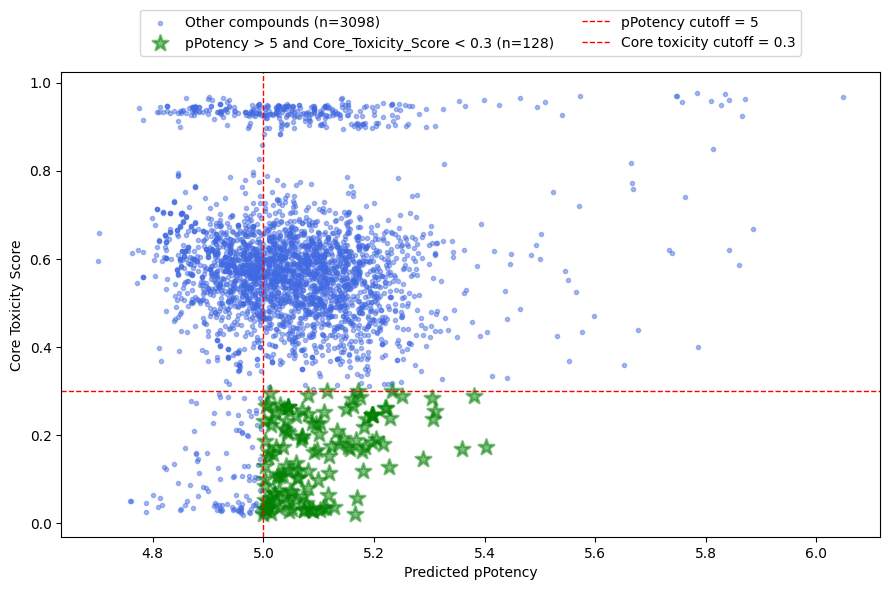

In [74]:
plotDF = combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity_sorted.copy()
highlightDF = combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity_core.copy()

# Rebuild mask from predefined cutoffs
highlightMask = (
    (plotDF["pPotency_prediction"] > pPotency_prediction_cutoff) &
    (plotDF["Core_Toxicity_Score"] < Core_Toxicity_cutoff)
)

backgroundDF = plotDF[~highlightMask]

otherCount = len(backgroundDF)
highlightCount = len(highlightDF)

plt.figure(figsize=(9, 6))

# Plot all other compounds
plt.scatter(
    backgroundDF["pPotency_prediction"],
    backgroundDF["Core_Toxicity_Score"],
    alpha=0.45,
    marker=".",
    c="royalblue",
    label=f"Other compounds (n={otherCount})"
)

# Plot filtered core compounds
plt.scatter(
    highlightDF["pPotency_prediction"],
    highlightDF["Core_Toxicity_Score"],
    alpha=0.5,
    marker="*",
    s=140,
    c="g",
    linewidths=1.8,
    label=f"pPotency > {pPotency_prediction_cutoff} and Core_Toxicity_Score < {Core_Toxicity_cutoff} (n={highlightCount})"
)

plt.axvline(
    x=pPotency_prediction_cutoff,
    c="r",
    linestyle="--",
    linewidth=1,
    label=f"pPotency cutoff = {pPotency_prediction_cutoff}"
)

plt.axhline(
    y=Core_Toxicity_cutoff,
    c="r",
    linestyle="--",
    linewidth=1,
    label=f"Core toxicity cutoff = {Core_Toxicity_cutoff}"
)

plt.xlabel("Predicted pPotency")
plt.ylabel("Core Toxicity Score")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=2)
plt.tight_layout()
plt.show()

### Create filtered dataframe with `Mechanistic_Alert_Score` & `ADME_Liability_Score`

In [75]:
# Select best overall compounds
combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity_allEndpoints = (
    combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity_sorted[
        (combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity_sorted["pPotency_prediction"] >= pPotency_prediction_cutoff) &
        (combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity_sorted["Core_Toxicity_Score"] < Core_Toxicity_cutoff) &
        (combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity_sorted["Mechanistic_Alert_Score"] < Mechanistic_Alert_cutoff) &
        (combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity_sorted["ADME_Liability_Score"] < ADME_Liability_cutoff)
    ]
    .copy()
)


combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity_allEndpoints.to_csv(resultsDir + 
                                                                           'combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity_allEndpoints.csv', index=False, encoding="utf-8")
combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity_allEndpoints

,SMILES,pPotency_prediction,pPotency_std,Core_Toxicity_Desirability,Core_Toxicity_Score,Mechanistic_Alert_Desirability,Mechanistic_Alert_Score,ADME_Desirability,ADME_Liability_Score,Safety_MPO_Desirability,Safety_MPO_RiskScore,Scoring_Method_Markdown


Total compounds: 3226
Best overall compounds: 0


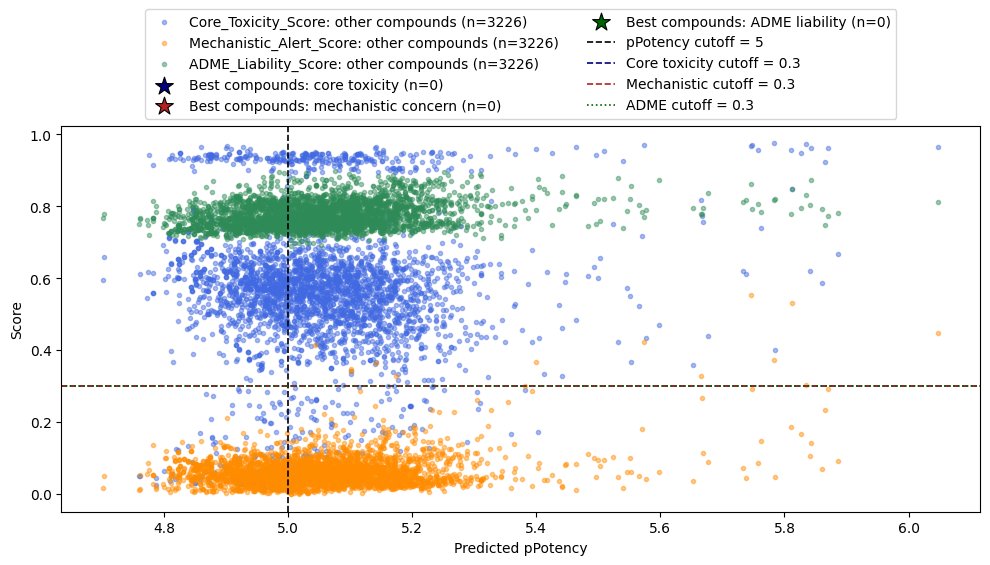

In [76]:
plotDF = combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity_sorted.copy()

highlightMask = (
    (plotDF["pPotency_prediction"] >= pPotency_prediction_cutoff) &
    (plotDF["Core_Toxicity_Score"] < Core_Toxicity_cutoff) &
    (plotDF["Mechanistic_Alert_Score"] < Mechanistic_Alert_cutoff) &
    (plotDF["ADME_Liability_Score"] < ADME_Liability_cutoff)
)

backgroundDF = plotDF[~highlightMask]
highlightDF = plotDF[highlightMask].copy()

otherCount = len(backgroundDF)
highlightCount = len(highlightDF)
totalCount = len(plotDF)

print("Total compounds:", totalCount)
print("Best overall compounds:", highlightCount)

plt.figure(figsize=(10, 6))

# Full distributions
plt.scatter(
    backgroundDF["pPotency_prediction"],
    backgroundDF["Core_Toxicity_Score"],
    alpha=0.45,
    marker=".",
    c="royalblue",
    label=f"Core_Toxicity_Score: other compounds (n={otherCount})"
)

plt.scatter(
    backgroundDF["pPotency_prediction"],
    backgroundDF["Mechanistic_Alert_Score"],
    alpha=0.45,
    marker=".",
    c="darkorange",
    label=f"Mechanistic_Alert_Score: other compounds (n={otherCount})"
)

plt.scatter(
    backgroundDF["pPotency_prediction"],
    backgroundDF["ADME_Liability_Score"],
    alpha=0.45,
    marker=".",
    c="seagreen",
    label=f"ADME_Liability_Score: other compounds (n={otherCount})"
)

# Highlight best compounds
plt.scatter(
    highlightDF["pPotency_prediction"],
    highlightDF["Core_Toxicity_Score"],
    alpha=1.0,
    marker="*",
    s=180,
    c="navy",
    edgecolors="black",
    linewidths=0.8,
    label=f"Best compounds: core toxicity (n={highlightCount})"
)

plt.scatter(
    highlightDF["pPotency_prediction"],
    highlightDF["Mechanistic_Alert_Score"],
    alpha=1.0,
    marker="*",
    s=180,
    c="firebrick",
    edgecolors="black",
    linewidths=0.8,
    label=f"Best compounds: mechanistic concern (n={highlightCount})"
)

plt.scatter(
    highlightDF["pPotency_prediction"],
    highlightDF["ADME_Liability_Score"],
    alpha=1.0,
    marker="*",
    s=180,
    c="darkgreen",
    edgecolors="black",
    linewidths=0.8,
    label=f"Best compounds: ADME liability (n={highlightCount})"
)

plt.axvline(
    x=pPotency_prediction_cutoff,
    c="black",
    linestyle="--",
    linewidth=1.2,
    label=f"pPotency cutoff = {pPotency_prediction_cutoff}"
)

plt.axhline(
    y=Core_Toxicity_cutoff,
    c="navy",
    linestyle="--",
    linewidth=1.2,
    label=f"Core toxicity cutoff = {Core_Toxicity_cutoff}"
)

plt.axhline(
    y=Mechanistic_Alert_cutoff,
    c="firebrick",
    linestyle="--",
    linewidth=1.2,
    label=f"Mechanistic cutoff = {Mechanistic_Alert_cutoff}"
)

plt.axhline(
    y=ADME_Liability_cutoff,
    c="darkgreen",
    linestyle=":",
    linewidth=1.2,
    label=f"ADME cutoff = {ADME_Liability_cutoff}"
)

plt.xlabel("Predicted pPotency")
plt.ylabel("Score")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.32), ncol=2)
plt.tight_layout()
plt.show()